In [ ]:


# CELL 1 — Install Kaggle

!pip -q install kaggle

In [ ]:


# CELL 2 — Upload kaggle.json

from google.colab import files
import os
import shutil

uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

uploaded_filename = list(uploaded.keys())[0]
print(f"Detected uploaded file: {uploaded_filename}")

shutil.move(uploaded_filename, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API credentials configured successfully.")

Saving kaggle.json to kaggle.json
Detected uploaded file: kaggle.json
Kaggle API credentials configured successfully.


In [ ]:

# CELL 3 — Download and unzip the Artificial Lunar Landscape Dataset

import os

KAGGLE_DATASET_SLUG = "romainpessia/artificial-lunar-rocky-landscape-dataset"
KAGGLE_DOWNLOAD_DIR = "/content/data/artificial_lunar_landscape"

os.makedirs(KAGGLE_DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p {KAGGLE_DOWNLOAD_DIR} --unzip

print(f"Dataset downloaded to: {KAGGLE_DOWNLOAD_DIR}")

Dataset URL: https://www.kaggle.com/datasets/romainpessia/artificial-lunar-rocky-landscape-dataset
License(s): CC-BY-NC-SA-4.0
100% 5.02G/5.02G [00:53<00:00, 100MB/s] 

Dataset downloaded to: /content/data/artificial_lunar_landscape


In [ ]:

# CELL 4 — Core Imports


from __future__ import annotations

import os
import re
import math
import copy
import json
import time
import random
from dataclasses import dataclass, field
from typing import Dict, Any, Optional, Tuple, List, Sequence, Callable, Union

import numpy as np
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
import torchvision.transforms as T
from torchvision import models

import matplotlib.pyplot as plt

In [ ]:

# CELL 5 — Common Utilities


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def is_image_file(filename: str) -> bool:
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    return filename.lower().endswith(valid_ext)

def safe_listdir(path: str) -> List[str]:
    if not os.path.isdir(path):
        return []
    return sorted(os.listdir(path))

def pil_loader(path: str, image_mode: str = "RGB") -> Image.Image:
    with Image.open(path) as img:
        return img.convert(image_mode)

def discover_best_image_directory(dataset_root: str) -> str:
    if not os.path.isdir(dataset_root):
        raise FileNotFoundError(f"Dataset root does not exist: {dataset_root}")

    preferred_keywords = ("image", "images", "render", "rendered", "rgb", "raw")
    excluded_keywords = (
        "mask", "masks", "label", "labels", "ground_truth", "groundtruth",
        "seg", "segment", "segmentation", "clean", "cleaned", "bbox", "box", "annotation"
    )

    candidates = []
    for root, dirs, files in os.walk(dataset_root):
        image_count = sum(1 for f in files if is_image_file(f))
        if image_count == 0:
            continue

        root_lower = root.lower()
        score = image_count

        if any(k in root_lower for k in preferred_keywords):
            score += 500
        if any(k in root_lower for k in excluded_keywords):
            score -= 1000

        candidates.append((score, image_count, root))

    if not candidates:
        raise ValueError(f"No image-containing directories were found under: {dataset_root}")

    candidates.sort(reverse=True)
    best_score, best_count, best_path = candidates[0]

    if best_count == 0:
        raise ValueError(f"No valid image directory found under: {dataset_root}")

    return best_path

In [ ]:
# CELL 6 — Data Engine Config


@dataclass
class DataEngineConfig:

    image_size: Tuple[int, int] = (224, 224)
    image_mode: str = "RGB"

    train_ratio: float = 0.7
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    batch_size: int = 16
    num_workers: int = 2
    pin_memory: bool = True


    mean: Tuple[float, float, float] = (0.5, 0.5, 0.5)
    std: Tuple[float, float, float] = (0.5, 0.5, 0.5)

    use_augmentation: bool = True
    horizontal_flip_prob: float = 0.5
    rotation_degrees: float = 10.0
    brightness_jitter: float = 0.2
    contrast_jitter: float = 0.2
    gaussian_blur_prob: float = 0.2
    grayscale_prob: float = 0.0

    seed: int = 42

In [ ]:
# CELL 7 — Data Engine Augmentation Blocks


class RandomShadow:
    def __init__(self, probability: float = 0.3, shadow_factor_range: Tuple[float, float] = (0.4, 0.8)):
        self.probability = probability
        self.shadow_factor_range = shadow_factor_range

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() > self.probability:
            return img

        img_np = np.array(img).astype(np.float32)
        h, w = img_np.shape[:2]

        x1, y1 = random.randint(0, w - 1), random.randint(0, h - 1)
        x2, y2 = random.randint(0, w - 1), random.randint(0, h - 1)

        yy, xx = np.mgrid[0:h, 0:w]
        mask = ((xx - x1) * (y2 - y1) - (yy - y1) * (x2 - x1)) >= 0

        shadow_factor = random.uniform(*self.shadow_factor_range)

        if img_np.ndim == 2:
            img_np[mask] *= shadow_factor
        else:
            img_np[mask, :] *= shadow_factor

        img_np = np.clip(img_np, 0, 255).astype(np.uint8)
        return Image.fromarray(img_np)

class RandomLunarNoise:
    def __init__(self, probability: float = 0.3, noise_std: float = 8.0):
        self.probability = probability
        self.noise_std = noise_std

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() > self.probability:
            return img

        img_np = np.array(img).astype(np.float32)
        noise = np.random.normal(0.0, self.noise_std, size=img_np.shape)
        img_np = np.clip(img_np + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(img_np)

class RandomGaussianBlur:
    def __init__(self, probability: float = 0.2, radius_range: Tuple[float, float] = (0.2, 1.2)):
        self.probability = probability
        self.radius_range = radius_range

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() > self.probability:
            return img
        radius = random.uniform(*self.radius_range)
        return img.filter(ImageFilter.GaussianBlur(radius=radius))

In [ ]:
# CELL 8 — Data Engine Transform Builder


class TransformFactory:
    def __init__(self, config: DataEngineConfig):
        self.config = config

    def build_train_transform(self) -> Callable:
        transforms: List[Callable] = [
            T.Resize(self.config.image_size),
        ]

        if self.config.use_augmentation:
            transforms.extend([
                T.RandomHorizontalFlip(p=self.config.horizontal_flip_prob),
                T.RandomRotation(degrees=self.config.rotation_degrees),
                T.ColorJitter(
                    brightness=self.config.brightness_jitter,
                    contrast=self.config.contrast_jitter,
                ),
                RandomShadow(probability=0.3),
                RandomLunarNoise(probability=0.3, noise_std=6.0),
                RandomGaussianBlur(probability=self.config.gaussian_blur_prob),
            ])

            if self.config.grayscale_prob > 0:
                transforms.append(T.RandomGrayscale(p=self.config.grayscale_prob))

        transforms.extend([
            T.ToTensor(),
            T.Normalize(mean=self.config.mean, std=self.config.std),
        ])

        return T.Compose(transforms)

    def build_eval_transform(self) -> Callable:
        return T.Compose([
            T.Resize(self.config.image_size),
            T.ToTensor(),
            T.Normalize(mean=self.config.mean, std=self.config.std),
        ])

In [ ]:
# CELL 9 — Data Engine Dataset


class LunarImageDataset(Dataset):
    def __init__(
        self,
        image_dir: str,
        image_paths: Optional[List[str]] = None,
        transform: Optional[Callable] = None,
        image_mode: str = "RGB",
        source_name: str = "unknown",
    ) -> None:
        self.image_dir = image_dir
        self.transform = transform
        self.image_mode = image_mode
        self.source_name = source_name

        if image_paths is not None:
            self.image_paths = image_paths
        else:
            self.image_paths = [
                os.path.join(image_dir, fname)
                for fname in safe_listdir(image_dir)
                if is_image_file(fname)
            ]

        if len(self.image_paths) == 0:
            raise ValueError(f"No image files found in directory: {image_dir}")

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        img_path = self.image_paths[idx]
        image = pil_loader(img_path, image_mode=self.image_mode)

        if self.transform is not None:
            image = self.transform(image)

        sample = {
            "image": image,
            "source_id": torch.tensor([self._source_to_id()], dtype=torch.long).squeeze(0),
        }
        return sample

    def _source_to_id(self) -> int:
        mapping = {
            "kaggle_artificial_lunar": 0,
            "lroc": 1,
            "lusnar": 2,
        }
        return mapping.get(self.source_name.lower(), 99)

In [ ]:
# CELL 10 — Data Engine


class DataEngine:
    def __init__(self, config: DataEngineConfig):
        self.config = config
        self.transform_factory = TransformFactory(config)
        set_seed(config.seed)

        total = config.train_ratio + config.val_ratio + config.test_ratio
        if not math.isclose(total, 1.0, rel_tol=1e-6, abs_tol=1e-6):
            raise ValueError(f"Split ratios must sum to 1.0, got {total}")

    def build_dataset_from_directory(
        self,
        image_dir: str,
        source_name: str,
        train: bool = True,
        image_paths: Optional[List[str]] = None,
    ) -> LunarImageDataset:
        transform = (
            self.transform_factory.build_train_transform()
            if train else self.transform_factory.build_eval_transform()
        )

        return LunarImageDataset(
            image_dir=image_dir,
            image_paths=image_paths,
            transform=transform,
            image_mode=self.config.image_mode,
            source_name=source_name,
        )

    def build_kaggle_artificial_lunar_dataset(
        self,
        dataset_root: str,
        train: bool = True,
        image_paths: Optional[List[str]] = None,
    ) -> LunarImageDataset:
        image_dir = discover_best_image_directory(dataset_root)
        print(f"Using Kaggle image directory: {image_dir}")

        return self.build_dataset_from_directory(
            image_dir=image_dir,
            source_name="kaggle_artificial_lunar",
            train=train,
            image_paths=image_paths,
        )

    def combine_datasets(self, datasets: Sequence[Dataset]) -> ConcatDataset:
        if len(datasets) == 0:
            raise ValueError("At least one dataset must be provided.")
        return ConcatDataset(datasets)

    def split_image_paths(self, image_paths: List[str]) -> Tuple[List[str], List[str], List[str]]:
        total_len = len(image_paths)

        train_len = int(total_len * self.config.train_ratio)
        val_len = int(total_len * self.config.val_ratio)
        test_len = total_len - train_len - val_len

        rng = random.Random(self.config.seed)
        shuffled = image_paths.copy()
        rng.shuffle(shuffled)

        train_paths = shuffled[:train_len]
        val_paths = shuffled[train_len:train_len + val_len]
        test_paths = shuffled[train_len + val_len:]

        return train_paths, val_paths, test_paths

    def build_dataloaders(
        self,
        train_set: Dataset,
        val_set: Dataset,
        test_set: Dataset,
    ) -> Dict[str, DataLoader]:
        train_loader = DataLoader(
            train_set,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

        val_loader = DataLoader(
            val_set,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

        test_loader = DataLoader(
            test_set,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

        return {
            "train": train_loader,
            "val": val_loader,
            "test": test_loader,
        }

    def compute_dataset_mean_std(
        self,
        image_dir: str,
        source_name: str,
        image_paths: Optional[List[str]] = None,
        max_batches: int = 50,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        stats_transform = T.Compose([
            T.Resize(self.config.image_size),
            T.ToTensor(),
        ])

        dataset = LunarImageDataset(
            image_dir=image_dir,
            image_paths=image_paths,
            transform=stats_transform,
            image_mode=self.config.image_mode,
            source_name=source_name,
        )

        loader = DataLoader(
            dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

        channel_sum = 0.0
        channel_sq_sum = 0.0
        num_pixels = 0

        for batch_idx, batch in enumerate(loader):
            images = batch["image"]

            b, c, h, w = images.shape
            pixels_per_batch = b * h * w

            channel_sum += images.sum(dim=[0, 2, 3])
            channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
            num_pixels += pixels_per_batch

            if batch_idx + 1 >= max_batches:
                break

        mean = channel_sum / num_pixels
        std = torch.sqrt((channel_sq_sum / num_pixels) - (mean ** 2))
        return mean, std


def build_ghidorah_lite_data_engine(
    kaggle_dataset_root: str,
    config: Optional[DataEngineConfig] = None,
) -> Tuple[DataEngine, Dict[str, DataLoader], Dict[str, Dataset]]:
    if config is None:
        config = DataEngineConfig()

    engine = DataEngine(config=config)

    image_dir = discover_best_image_directory(kaggle_dataset_root)
    all_image_paths = [
        os.path.join(image_dir, fname)
        for fname in safe_listdir(image_dir)
        if is_image_file(fname)
    ]

    train_paths, val_paths, test_paths = engine.split_image_paths(all_image_paths)

    train_set = engine.build_dataset_from_directory(
        image_dir=image_dir,
        source_name="kaggle_artificial_lunar",
        train=True,
        image_paths=train_paths,
    )

    val_set = engine.build_dataset_from_directory(
        image_dir=image_dir,
        source_name="kaggle_artificial_lunar",
        train=False,
        image_paths=val_paths,
    )

    test_set = engine.build_dataset_from_directory(
        image_dir=image_dir,
        source_name="kaggle_artificial_lunar",
        train=False,
        image_paths=test_paths,
    )

    loaders = engine.build_dataloaders(train_set, val_set, test_set)

    datasets = {
        "train": train_set,
        "val": val_set,
        "test": test_set,
    }

    return engine, loaders, datasets

In [ ]:
# CELL 11 — Build Data Engine


config = DataEngineConfig(
    image_size=(224, 224),
    batch_size=8,
    use_augmentation=True,
    seed=42,
)

engine, loaders, datasets = build_ghidorah_lite_data_engine(
    kaggle_dataset_root=KAGGLE_DOWNLOAD_DIR,
    config=config,
)

print("GHIDORAH-Lite Data Engine initialized successfully.")
print(f"Train dataset size: {len(datasets['train'])}")
print(f"Val dataset size: {len(datasets['val'])}")
print(f"Test dataset size: {len(datasets['test'])}")
print(f"Total dataset size: {len(datasets['train']) + len(datasets['val']) + len(datasets['test'])}")

for split_name, dataset in datasets.items():
    print(f"{split_name} dataset size: {len(dataset)}")

for split_name, loader in loaders.items():
    first_batch = next(iter(loader))
    print(f"{split_name} batch image shape: {first_batch['image'].shape}")
    print(f"{split_name} source IDs shape: {first_batch['source_id'].shape}")

GHIDORAH-Lite Data Engine initialized successfully.
Train dataset size: 6836
Val dataset size: 1464
Test dataset size: 1466
Total dataset size: 9766
train dataset size: 6836
val dataset size: 1464
test dataset size: 1466
train batch image shape: torch.Size([8, 3, 224, 224])
train source IDs shape: torch.Size([8])
val batch image shape: torch.Size([8, 3, 224, 224])
val source IDs shape: torch.Size([8])
test batch image shape: torch.Size([8, 3, 224, 224])
test source IDs shape: torch.Size([8])


In [ ]:
# CELL 12 — Shared Backbone Config + Utility Blocks


@dataclass
class SharedBackboneConfig:
    backbone_name: str = "resnet18"
    pretrained: bool = True
    in_channels: int = 3
    freeze_stem: bool = False
    freeze_backbone: bool = False

    f1_out_channels: int = 64
    f2_out_channels: int = 128
    f3_out_channels: int = 256

    use_feature_projections: bool = True

class ConvBNReLU(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
    ) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class FeatureProjection(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            ConvBNReLU(out_channels, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)

In [ ]:
# CELL 13 — Shared Backbone

class SharedBackbone(nn.Module):
    def __init__(self, config: SharedBackboneConfig) -> None:
        super().__init__()
        self.config = config

        backbone_name = config.backbone_name.lower()

        if backbone_name == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if config.pretrained else None
            backbone = models.resnet18(weights=weights)
            raw_channels = {"f1": 64, "f2": 128, "f3": 256, "deep": 512}
        elif backbone_name == "resnet34":
            weights = models.ResNet34_Weights.DEFAULT if config.pretrained else None
            backbone = models.resnet34(weights=weights)
            raw_channels = {"f1": 64, "f2": 128, "f3": 256, "deep": 512}
        else:
            raise ValueError(
                f"Unsupported backbone_name: {config.backbone_name}. "
                "Supported options: 'resnet18', 'resnet34'."
            )

        # Preserve pretrained conv1 information as much as possible when
        # config.in_channels != 3 instead of replacing conv1 with a randomly
        # initialized layer that discards all first-layer pretrained structure.
        if config.in_channels != 3:
            old_conv1 = backbone.conv1
            new_conv1 = nn.Conv2d(
                in_channels=config.in_channels,
                out_channels=old_conv1.out_channels,
                kernel_size=old_conv1.kernel_size,
                stride=old_conv1.stride,
                padding=old_conv1.padding,
                bias=False,
            )

            with torch.no_grad():
                if config.pretrained:
                    old_weight = old_conv1.weight  # [64, 3, 7, 7]

                    if config.in_channels == 1:
                        # Average RGB filters into a single grayscale channel
                        new_weight = old_weight.mean(dim=1, keepdim=True)
                    elif config.in_channels > 3:
                        # Copy RGB weights into first 3 channels, then repeat the
                        # mean RGB filter for any additional channels.
                        new_weight = torch.zeros(
                            (old_weight.shape[0], config.in_channels, *old_weight.shape[2:]),
                            dtype=old_weight.dtype,
                            device=old_weight.device,
                        )
                        new_weight[:, :3, :, :] = old_weight
                        mean_channel = old_weight.mean(dim=1, keepdim=True)
                        for c in range(3, config.in_channels):
                            new_weight[:, c:c+1, :, :] = mean_channel
                    else:
                        # For 2-channel input, use the first N pretrained channels.
                        new_weight = old_weight[:, :config.in_channels, :, :]

                    new_conv1.weight.copy_(new_weight)
                else:
                    nn.init.kaiming_normal_(new_conv1.weight, mode="fan_out", nonlinearity="relu")

            backbone.conv1 = new_conv1

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.use_feature_projections = config.use_feature_projections

        if self.use_feature_projections:
            self.f1_proj = FeatureProjection(raw_channels["f1"], config.f1_out_channels)
            self.f2_proj = FeatureProjection(raw_channels["f2"], config.f2_out_channels)
            self.f3_proj = FeatureProjection(raw_channels["f3"], config.f3_out_channels)
        else:
            self.f1_proj = nn.Identity()
            self.f2_proj = nn.Identity()
            self.f3_proj = nn.Identity()

        self.raw_channels = raw_channels
        self._apply_freezing()

    def _apply_freezing(self) -> None:

        # freeze_stem only freezes the stem.
        if self.config.freeze_stem:
            for param in self.stem.parameters():
                param.requires_grad = False

        # freeze_backbone now freezes only the ResNet backbone body
        # and does NOT automatically freeze the feature projection layers.
        if self.config.freeze_backbone:
            backbone_modules = [
                self.stem,
                self.layer1,
                self.layer2,
                self.layer3,
                self.layer4,
            ]
            for module in backbone_modules:
                for param in module.parameters():
                    param.requires_grad = False

    def _extract_input_tensor(
        self,
        x: Union[torch.Tensor, Dict[str, torch.Tensor]]
    ) -> torch.Tensor:
        if isinstance(x, dict):
            if "image" not in x:
                raise KeyError(
                    "Input batch dictionary must contain an 'image' key."
                )
            x = x["image"]

        if not isinstance(x, torch.Tensor):
            raise TypeError(
                "SharedBackbone input must be either a torch.Tensor "
                "or a dictionary containing an 'image' tensor."
            )

        if x.ndim != 4:
            raise ValueError(
                f"Expected input tensor shape [B, C, H, W], got shape {tuple(x.shape)}"
            )

        if x.shape[1] != self.config.in_channels:
            raise ValueError(
                f"Expected {self.config.in_channels} input channels, "
                f"but got {x.shape[1]}."
            )

        return x

    def forward(
        self,
        x: Union[torch.Tensor, Dict[str, torch.Tensor]]
    ) -> Dict[str, torch.Tensor]:
        x = self._extract_input_tensor(x)

        x = self.stem(x)

        f1_raw = self.layer1(x)
        f2_raw = self.layer2(f1_raw)
        f3_raw = self.layer3(f2_raw)
        deep = self.layer4(f3_raw)

        f1 = self.f1_proj(f1_raw)
        f2 = self.f2_proj(f2_raw)
        f3 = self.f3_proj(f3_raw)

        return {
            "f1": f1,
            "f2": f2,
            "f3": f3,
            "deep": deep,
        }

    def get_output_channels(self) -> Dict[str, int]:
        if self.use_feature_projections:
            return {
                "f1": self.config.f1_out_channels,
                "f2": self.config.f2_out_channels,
                "f3": self.config.f3_out_channels,
                "deep": self.raw_channels["deep"],
            }

        return self.raw_channels.copy()

    def get_feature_shapes(
        self,
        input_shape: Optional[Tuple[int, int, int, int]] = None,
        device: str = "cpu",
    ) -> Dict[str, Tuple[int, ...]]:


        if input_shape is None:
            input_shape = (1, self.config.in_channels, 224, 224)


        # Preserve and restore training mode and original device so this helper
        # does not permanently mutate model state.
        was_training = self.training
        try:
            original_device = next(self.parameters()).device
        except StopIteration:
            original_device = torch.device("cpu")

        target_device = torch.device(device)

        self.eval()
        self.to(target_device)

        dummy = torch.randn(*input_shape, device=target_device)

        with torch.no_grad():
            outputs = self(dummy)

        shapes = {name: tuple(feat.shape) for name, feat in outputs.items()}

        self.to(original_device)
        if was_training:
            self.train()
        else:
            self.eval()

        return shapes

In [ ]:


# CELL 14 — Shared Backbone Test


backbone_model = SharedBackbone(
    SharedBackboneConfig(
        backbone_name="resnet18",
        pretrained=False,
        in_channels=3,
        freeze_stem=False,
        freeze_backbone=False,
        f1_out_channels=64,
        f2_out_channels=128,
        f3_out_channels=256,
        use_feature_projections=True,
    )
)

batch = next(iter(loaders["train"]))
backbone_outputs = backbone_model(batch)

print("Integrated Data Engine + Shared Backbone test:")
print("Input image batch shape:", batch["image"].shape)
print("Source IDs:", batch["source_id"][:8])

for name, feat in backbone_outputs.items():
    print(f"{name}: {feat.shape}")

Integrated Data Engine + Shared Backbone test:
Input image batch shape: torch.Size([8, 3, 224, 224])
Source IDs: tensor([0, 0, 0, 0, 0, 0, 0, 0])
f1: torch.Size([8, 64, 56, 56])
f2: torch.Size([8, 128, 28, 28])
f3: torch.Size([8, 256, 14, 14])
deep: torch.Size([8, 512, 7, 7])


In [ ]:


# CELL 15 — Feature Analyzer Config + Utility Layers


@dataclass
class FeatureAnalyzerConfig:
    use_learned_task_scoring: bool = True
    hidden_dim: int = 64
    dropout: float = 0.1
    activation: str = "relu"
    task_names: Tuple[str, ...] = (
        "segmentation",
        "detection",
        "geometry",
    )

    def __post_init__(self) -> None:
        if len(self.task_names) == 0:
            raise ValueError("FeatureAnalyzerConfig.task_names must not be empty")

        if self.hidden_dim <= 0:
            raise ValueError("FeatureAnalyzerConfig.hidden_dim must be > 0")

        if not (0.0 <= self.dropout < 1.0):
            raise ValueError("FeatureAnalyzerConfig.dropout must be in [0.0, 1.0)")

        valid_activations = {"relu", "gelu", "silu"}
        if self.activation.lower() not in valid_activations:
            raise ValueError(
                f"Unsupported activation: {self.activation}. "
                f"Supported options: {sorted(valid_activations)}"
            )

def build_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "silu":
        return nn.SiLU()
    raise ValueError(f"Unsupported activation: {name}")

class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        dropout: float,
        activation: str = "relu",
    ) -> None:
        super().__init__()

        if in_dim <= 0:
            raise ValueError("MLP in_dim must be > 0")
        if hidden_dim <= 0:
            raise ValueError("MLP hidden_dim must be > 0")
        if out_dim <= 0:
            raise ValueError("MLP out_dim must be > 0")
        if not (0.0 <= dropout < 1.0):
            raise ValueError("MLP dropout must be in [0.0, 1.0)")

        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.dropout = dropout
        self.activation_name = activation.lower()

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            build_activation(self.activation_name),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}("
            f"in_dim={self.in_dim}, "
            f"hidden_dim={self.hidden_dim}, "
            f"out_dim={self.out_dim}, "
            f"dropout={self.dropout}, "
            f"activation='{self.activation_name}')"
        )

In [ ]:

# CELL 16 — Feature Analyzer


class FeatureAnalyzer(nn.Module):
    def __init__(self, config: FeatureAnalyzerConfig):
        super().__init__()
        self.config = config
        self.task_dim = len(config.task_names)

        self.num_stats_per_feature = 7
        self.num_feature_levels = 3
        self.stats_dim = self.num_stats_per_feature * self.num_feature_levels

        if config.use_learned_task_scoring:
            self.task_head = MLP(
                in_dim=self.stats_dim,
                hidden_dim=config.hidden_dim,
                out_dim=self.task_dim,
                dropout=config.dropout,
                activation=config.activation,
            )

            self.feature_pref_head = MLP(
                in_dim=self.stats_dim,
                hidden_dim=config.hidden_dim,
                out_dim=3,
                dropout=config.dropout,
                activation=config.activation,
            )

    def _descriptor(self, x: torch.Tensor) -> torch.Tensor:
        return F.adaptive_avg_pool2d(x, 1).view(x.size(0), -1)

    def _stats(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=[1, 2, 3])
        std = x.std(dim=[1, 2, 3], unbiased=False)
        max_val = x.amax(dim=[1, 2, 3])
        min_val = x.amin(dim=[1, 2, 3])
        energy = (x ** 2).mean(dim=[1, 2, 3])
        l1 = x.abs().mean(dim=[1, 2, 3])
        sparsity = (x.abs() < 1e-3).float().mean(dim=[1, 2, 3])

        stats = torch.stack(
            [mean, std, max_val, min_val, energy, l1, sparsity],
            dim=1,
        )
        return stats

    def forward(self, features: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        required_keys = ["f1", "f2", "f3"]
        if not all(k in features for k in required_keys):
            raise KeyError("FeatureAnalyzer requires keys: f1, f2, f3")

        f1 = features["f1"]
        f2 = features["f2"]
        f3 = features["f3"]

        if not (f1.size(0) == f2.size(0) == f3.size(0)):
            raise ValueError("FeatureAnalyzer inputs must have matching batch dimensions.")

        f1_desc = self._descriptor(f1)
        f2_desc = self._descriptor(f2)
        f3_desc = self._descriptor(f3)

        f1_stats = self._stats(f1)
        f2_stats = self._stats(f2)
        f3_stats = self._stats(f3)

        stats_vector = torch.cat([f1_stats, f2_stats, f3_stats], dim=1)

        if self.config.use_learned_task_scoring:
            task_scores = torch.softmax(self.task_head(stats_vector), dim=1)
            feature_pref = torch.softmax(self.feature_pref_head(stats_vector), dim=1)
        else:
            B = stats_vector.size(0)
            task_scores = torch.ones(B, self.task_dim, device=stats_vector.device) / self.task_dim
            feature_pref = torch.ones(B, 3, device=stats_vector.device) / 3

        return {
            "f1_descriptor": f1_desc,
            "f2_descriptor": f2_desc,
            "f3_descriptor": f3_desc,
            "stats_vector": stats_vector,
            "task_scores": task_scores,
            "feature_preference_scores": feature_pref,
        }

In [ ]:

# CELL 17 — Feature Analyzer Test


analyzer = FeatureAnalyzer(
    FeatureAnalyzerConfig(
        use_learned_task_scoring=True,
        hidden_dim=64,
        dropout=0.1,
        activation="relu",
        task_names=("segmentation", "detection", "geometry"),
    )
)

analysis_outputs = analyzer(backbone_outputs)

print("Integrated GHIDORAH pipeline:\n")
print("Backbone:")
for k, v in backbone_outputs.items():
    print(f"{k}: {v.shape}")

print("\nAnalyzer:")
for k, v in analysis_outputs.items():
    print(f"{k}: {v.shape}")

print("\nTask Scores:\n", analysis_outputs["task_scores"])
print("\nFeature Preference:\n", analysis_outputs["feature_preference_scores"])

task_score_sums = analysis_outputs["task_scores"].sum(dim=1)
feature_pref_sums = analysis_outputs["feature_preference_scores"].sum(dim=1)

print("\nTask score row sums:\n", task_score_sums)
print("\nFeature preference row sums:\n", feature_pref_sums)

assert torch.allclose(
    task_score_sums,
    torch.ones_like(task_score_sums),
    atol=1e-5,
), "Task scores do not sum to 1."

assert torch.allclose(
    feature_pref_sums,
    torch.ones_like(feature_pref_sums),
    atol=1e-5,
), "Feature preference scores do not sum to 1."

print("\nFeature Analyzer softmax validation passed.")

Integrated GHIDORAH pipeline:

Backbone:
f1: torch.Size([8, 64, 56, 56])
f2: torch.Size([8, 128, 28, 28])
f3: torch.Size([8, 256, 14, 14])
deep: torch.Size([8, 512, 7, 7])

Analyzer:
f1_descriptor: torch.Size([8, 64])
f2_descriptor: torch.Size([8, 128])
f3_descriptor: torch.Size([8, 256])
stats_vector: torch.Size([8, 21])
task_scores: torch.Size([8, 3])
feature_preference_scores: torch.Size([8, 3])

Task Scores:
 tensor([[0.3071, 0.3234, 0.3695],
        [0.5421, 0.1819, 0.2761],
        [0.7455, 0.0995, 0.1550],
        [0.4602, 0.2115, 0.3283],
        [0.4902, 0.1853, 0.3245],
        [0.6337, 0.1314, 0.2350],
        [0.3481, 0.2311, 0.4208],
        [0.4761, 0.2307, 0.2932]], grad_fn=<SoftmaxBackward0>)

Feature Preference:
 tensor([[0.3091, 0.3710, 0.3199],
        [0.3865, 0.3777, 0.2358],
        [0.2404, 0.4187, 0.3408],
        [0.2600, 0.4397, 0.3003],
        [0.3094, 0.4160, 0.2745],
        [0.2426, 0.5112, 0.2462],
        [0.1576, 0.5037, 0.3387],
        [0.2002, 0.448

In [ ]:

# CELL 18 — Trunk Config + Utility Blocks


@dataclass
class TrunkConfig:
    f1_channels: int = 64
    f2_channels: int = 128
    f3_channels: int = 256
    trunk_channels: int = 128

    use_learned_selector: bool = True
    selector_hidden_dim: int = 128
    selector_dropout: float = 0.1
    selector_activation: str = "relu"

    task_names: Tuple[str, ...] = (
        "segmentation",
        "detection",
        "geometry",
    )

    trunk_instruction_names: Tuple[str, ...] = (
        "TRUNK_FPN_SEMANTIC",
        "TRUNK_DETECTION_PYRAMID",
        "TRUNK_GEOMETRY_REFINEMENT",
    )

    def __post_init__(self) -> None:
        channel_values = (
            self.f1_channels,
            self.f2_channels,
            self.f3_channels,
            self.trunk_channels,
        )
        if any(c <= 0 for c in channel_values):
            raise ValueError("All channel values in TrunkConfig must be > 0")

        if self.selector_hidden_dim <= 0:
            raise ValueError("selector_hidden_dim must be > 0")

        if not (0.0 <= self.selector_dropout < 1.0):
            raise ValueError("selector_dropout must be in [0.0, 1.0)")

        if len(self.task_names) == 0:
            raise ValueError("task_names must not be empty")

        if len(self.trunk_instruction_names) == 0:
            raise ValueError("trunk_instruction_names must not be empty")

        if len(self.task_names) != len(self.trunk_instruction_names):
            raise ValueError(
                "task_names and trunk_instruction_names must have the same length "
                "for GHIDORAH-Lite 1:1 task-to-trunk mapping."
            )

        valid_activations = {"relu", "gelu", "silu"}
        if self.selector_activation.lower() not in valid_activations:
            raise ValueError(
                f"Unsupported selector_activation: {self.selector_activation}. "
                f"Supported options: {sorted(valid_activations)}"
            )

def build_selector_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "gelu":
        return nn.GELU()
    if name == "silu":
        return nn.SiLU(inplace=True)
    raise ValueError(f"Unsupported selector activation: {name}")

class SelectorMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        dropout: float,
        activation: str = "relu",
    ) -> None:
        super().__init__()

        if input_dim <= 0:
            raise ValueError("SelectorMLP input_dim must be > 0")
        if hidden_dim <= 0:
            raise ValueError("SelectorMLP hidden_dim must be > 0")
        if output_dim <= 0:
            raise ValueError("SelectorMLP output_dim must be > 0")
        if not (0.0 <= dropout < 1.0):
            raise ValueError("SelectorMLP dropout must be in [0.0, 1.0)")

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.dropout = dropout
        self.activation_name = activation.lower()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            build_selector_activation(self.activation_name),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            build_selector_activation(self.activation_name),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}("
            f"input_dim={self.input_dim}, "
            f"hidden_dim={self.hidden_dim}, "
            f"output_dim={self.output_dim}, "
            f"dropout={self.dropout}, "
            f"activation='{self.activation_name}')"
        )


In [ ]:

# CELL 19 — Trunk Templates


class SemanticFPNTrunk(nn.Module):
    def __init__(
        self,
        f1_channels: int,
        f2_channels: int,
        f3_channels: int,
        trunk_channels: int,
    ) -> None:
        super().__init__()
        self.f1_proj = ConvBNReLU(f1_channels, trunk_channels, kernel_size=1, padding=0)
        self.f2_proj = ConvBNReLU(f2_channels, trunk_channels, kernel_size=1, padding=0)
        self.f3_proj = ConvBNReLU(f3_channels, trunk_channels, kernel_size=1, padding=0)

        self.refine_f2 = ConvBNReLU(trunk_channels, trunk_channels)
        self.refine_f1 = ConvBNReLU(trunk_channels, trunk_channels)
        self.out_refine = ConvBNReLU(trunk_channels, trunk_channels)

    def _validate_features(self, features: Dict[str, torch.Tensor]) -> None:
        required = ["f1", "f2", "f3"]
        for key in required:
            if key not in features:
                raise KeyError(f"SemanticFPNTrunk requires key '{key}'")

        tensors = {k: features[k] for k in required}
        for name, tensor in tensors.items():
            if not isinstance(tensor, torch.Tensor):
                raise TypeError(f"SemanticFPNTrunk expected '{name}' to be a torch.Tensor")
            if tensor.ndim != 4:
                raise ValueError(
                    f"SemanticFPNTrunk expected '{name}' shape [B, C, H, W], got {tuple(tensor.shape)}"
                )

        f1, f2, f3 = tensors["f1"], tensors["f2"], tensors["f3"]
        if not (f1.size(0) == f2.size(0) == f3.size(0)):
            raise ValueError("SemanticFPNTrunk requires f1, f2, and f3 to share the same batch size.")

    def forward(self, features: Dict[str, torch.Tensor]) -> Dict[str, Any]:
        self._validate_features(features)

        f1 = self.f1_proj(features["f1"])
        f2 = self.f2_proj(features["f2"])
        f3 = self.f3_proj(features["f3"])

        f3_up = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        fused_f2 = self.refine_f2(f2 + f3_up)

        fused_f2_up = F.interpolate(fused_f2, size=f1.shape[-2:], mode="bilinear", align_corners=False)
        fused_f1 = self.refine_f1(f1 + fused_f2_up)

        out = self.out_refine(fused_f1)

        return {
            "trunk_name": "TRUNK_FPN_SEMANTIC",
            "trunk_output": out,
            "aux_outputs": {
                "fused_f1": fused_f1,
                "fused_f2": fused_f2,
                "fused_f3": f3,
            },
        }


class DetectionPyramidTrunk(nn.Module):
    def __init__(
        self,
        f1_channels: int,
        f2_channels: int,
        f3_channels: int,
        trunk_channels: int,
    ) -> None:
        super().__init__()
        self.f1_proj = ConvBNReLU(f1_channels, trunk_channels, kernel_size=1, padding=0)
        self.f2_proj = ConvBNReLU(f2_channels, trunk_channels, kernel_size=1, padding=0)
        self.f3_proj = ConvBNReLU(f3_channels, trunk_channels, kernel_size=1, padding=0)

        self.p3 = ConvBNReLU(trunk_channels, trunk_channels)
        self.p2 = ConvBNReLU(trunk_channels, trunk_channels)
        self.p1 = ConvBNReLU(trunk_channels, trunk_channels)

    def _validate_features(self, features: Dict[str, torch.Tensor]) -> None:
        required = ["f1", "f2", "f3"]
        for key in required:
            if key not in features:
                raise KeyError(f"DetectionPyramidTrunk requires key '{key}'")

        tensors = {k: features[k] for k in required}
        for name, tensor in tensors.items():
            if not isinstance(tensor, torch.Tensor):
                raise TypeError(f"DetectionPyramidTrunk expected '{name}' to be a torch.Tensor")
            if tensor.ndim != 4:
                raise ValueError(
                    f"DetectionPyramidTrunk expected '{name}' shape [B, C, H, W], got {tuple(tensor.shape)}"
                )

        f1, f2, f3 = tensors["f1"], tensors["f2"], tensors["f3"]
        if not (f1.size(0) == f2.size(0) == f3.size(0)):
            raise ValueError("DetectionPyramidTrunk requires f1, f2, and f3 to share the same batch size.")

    def forward(self, features: Dict[str, torch.Tensor]) -> Dict[str, Any]:
        self._validate_features(features)

        f1 = self.f1_proj(features["f1"])
        f2 = self.f2_proj(features["f2"])
        f3 = self.f3_proj(features["f3"])

        p3 = self.p3(f3)
        p3_up = F.interpolate(p3, size=f2.shape[-2:], mode="bilinear", align_corners=False)

        p2 = self.p2(f2 + p3_up)
        p2_up = F.interpolate(p2, size=f1.shape[-2:], mode="bilinear", align_corners=False)

        p1 = self.p1(f1 + p2_up)

        return {
            "trunk_name": "TRUNK_DETECTION_PYRAMID",
            "trunk_output": p2,
            "aux_outputs": {
                "p1": p1,
                "p2": p2,
                "p3": p3,
            },
        }


class GeometryRefinementTrunk(nn.Module):
    def __init__(
        self,
        f1_channels: int,
        f2_channels: int,
        f3_channels: int,
        trunk_channels: int,
    ) -> None:
        super().__init__()
        self.f2_proj = ConvBNReLU(f2_channels, trunk_channels, kernel_size=1, padding=0)
        self.f3_proj = ConvBNReLU(f3_channels, trunk_channels, kernel_size=1, padding=0)

        self.merge = ConvBNReLU(trunk_channels * 2, trunk_channels)
        self.refine_1 = ConvBNReLU(trunk_channels, trunk_channels)
        self.refine_2 = ConvBNReLU(trunk_channels, trunk_channels)

    def _validate_features(self, features: Dict[str, torch.Tensor]) -> None:
        required = ["f2", "f3"]
        for key in required:
            if key not in features:
                raise KeyError(f"GeometryRefinementTrunk requires key '{key}'")

        tensors = {k: features[k] for k in required}
        for name, tensor in tensors.items():
            if not isinstance(tensor, torch.Tensor):
                raise TypeError(f"GeometryRefinementTrunk expected '{name}' to be a torch.Tensor")
            if tensor.ndim != 4:
                raise ValueError(
                    f"GeometryRefinementTrunk expected '{name}' shape [B, C, H, W], got {tuple(tensor.shape)}"
                )

        f2, f3 = tensors["f2"], tensors["f3"]
        if f2.size(0) != f3.size(0):
            raise ValueError("GeometryRefinementTrunk requires f2 and f3 to share the same batch size.")

    def forward(self, features: Dict[str, torch.Tensor]) -> Dict[str, Any]:
        self._validate_features(features)

        f2 = self.f2_proj(features["f2"])
        f3 = self.f3_proj(features["f3"])

        f3_up = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        merged = torch.cat([f2, f3_up], dim=1)

        x = self.merge(merged)
        x = self.refine_1(x)
        x = self.refine_2(x)

        return {
            "trunk_name": "TRUNK_GEOMETRY_REFINEMENT",
            "trunk_output": x,
            "aux_outputs": {
                "geometry_context": x,
                "coarse_geometry": f3,
            },
        }

In [ ]:

# CELL 20 — Trunk Instruction Set + Selector


class TrunkInstructionSet:
    def __init__(self, config: TrunkConfig) -> None:
        self.config = config

        self.registry = {
            "TRUNK_FPN_SEMANTIC": SemanticFPNTrunk,
            "TRUNK_DETECTION_PYRAMID": DetectionPyramidTrunk,
            "TRUNK_GEOMETRY_REFINEMENT": GeometryRefinementTrunk,
        }

        self._validate_instruction_set()

    def _validate_instruction_set(self) -> None:
        for name in self.config.trunk_instruction_names:
            if name not in self.registry:
                raise ValueError(f"Unknown trunk instruction name in config: {name}")

    def list_instructions(self) -> List[str]:
        return list(self.config.trunk_instruction_names)

    def build_trunk(self, instruction_name: str) -> nn.Module:
        if instruction_name not in self.registry:
            raise ValueError(f"Unsupported trunk instruction: {instruction_name}")

        trunk_cls = self.registry[instruction_name]
        return trunk_cls(
            f1_channels=self.config.f1_channels,
            f2_channels=self.config.f2_channels,
            f3_channels=self.config.f3_channels,
            trunk_channels=self.config.trunk_channels,
        )


class TrunkTemplateSelector(nn.Module):
    def __init__(self, config: TrunkConfig, instruction_set: TrunkInstructionSet) -> None:
        super().__init__()
        self.config = config
        self.instruction_set = instruction_set

        self.num_stats_dims = 21
        self.num_feature_pref_dims = 3
        self.selector_input_dim = self.num_stats_dims + len(config.task_names) + self.num_feature_pref_dims

        self.selector = SelectorMLP(
            input_dim=self.selector_input_dim,
            hidden_dim=config.selector_hidden_dim,
            output_dim=len(config.trunk_instruction_names),
            dropout=config.selector_dropout,
            activation=config.selector_activation,
        )

        self.default_task_to_instruction = {
            "segmentation": "TRUNK_FPN_SEMANTIC",
            "detection": "TRUNK_DETECTION_PYRAMID",
            "geometry": "TRUNK_GEOMETRY_REFINEMENT",
        }

        self._validate_default_mapping()

    def _validate_default_mapping(self) -> None:
        instruction_names = set(self.instruction_set.list_instructions())
        for task_name in self.config.task_names:
            if task_name not in self.default_task_to_instruction:
                raise ValueError(f"No default trunk instruction defined for task '{task_name}'")
            mapped_name = self.default_task_to_instruction[task_name]
            if mapped_name not in instruction_names:
                raise ValueError(
                    f"Default mapping for task '{task_name}' points to unknown instruction '{mapped_name}'"
                )

    def _validate_analysis_outputs(self, analysis_outputs: Dict[str, torch.Tensor]) -> None:
        required_keys = ["stats_vector", "task_scores", "feature_preference_scores"]
        for key in required_keys:
            if key not in analysis_outputs:
                raise KeyError(f"TrunkTemplateSelector requires analysis output key '{key}'")

        stats_vector = analysis_outputs["stats_vector"]
        task_scores = analysis_outputs["task_scores"]
        feature_preference_scores = analysis_outputs["feature_preference_scores"]

        for name, tensor in {
            "stats_vector": stats_vector,
            "task_scores": task_scores,
            "feature_preference_scores": feature_preference_scores,
        }.items():
            if not isinstance(tensor, torch.Tensor):
                raise TypeError(f"{name} must be a torch.Tensor")
            if tensor.ndim != 2:
                raise ValueError(f"{name} must have shape [B, D], got {tuple(tensor.shape)}")

        batch_size = stats_vector.size(0)
        if task_scores.size(0) != batch_size or feature_preference_scores.size(0) != batch_size:
            raise ValueError("All analysis output tensors must share the same batch size.")

        if stats_vector.size(1) != self.num_stats_dims:
            raise ValueError(
                f"Expected stats_vector dim {self.num_stats_dims}, got {stats_vector.size(1)}"
            )

        if task_scores.size(1) != len(self.config.task_names):
            raise ValueError(
                f"Expected task_scores dim {len(self.config.task_names)}, got {task_scores.size(1)}"
            )

        if feature_preference_scores.size(1) != self.num_feature_pref_dims:
            raise ValueError(
                f"Expected feature_preference_scores dim {self.num_feature_pref_dims}, "
                f"got {feature_preference_scores.size(1)}"
            )

    def _build_selector_input(self, analysis_outputs: Dict[str, torch.Tensor]) -> torch.Tensor:
        self._validate_analysis_outputs(analysis_outputs)

        stats_vector = analysis_outputs["stats_vector"]
        task_scores = analysis_outputs["task_scores"]
        feature_preference_scores = analysis_outputs["feature_preference_scores"]

        return torch.cat([stats_vector, task_scores, feature_preference_scores], dim=1)

    def _rule_based_select(
        self,
        analysis_outputs: Dict[str, torch.Tensor]
    ) -> Dict[str, Dict[str, Union[torch.Tensor, str]]]:
        self._validate_analysis_outputs(analysis_outputs)

        instruction_names = self.instruction_set.list_instructions()
        selection = {}

        for task_name in self.config.task_names:
            instruction_name = self.default_task_to_instruction[task_name]
            score_vec = torch.zeros(len(instruction_names), dtype=torch.float32)

            selected_idx = instruction_names.index(instruction_name)
            score_vec[selected_idx] = 1.0

            selection[task_name] = {
                "instruction_name": instruction_name,
                "selection_scores": score_vec,
            }

        return selection

    def _learned_select(
        self,
        analysis_outputs: Dict[str, torch.Tensor]
    ) -> Dict[str, Dict[str, Union[torch.Tensor, str]]]:
        selector_input = self._build_selector_input(analysis_outputs)
        logits = self.selector(selector_input)
        probs = F.softmax(logits, dim=1)
        avg_probs = probs.mean(dim=0)

        selection = {}
        instruction_names = self.instruction_set.list_instructions()

        for task_name in self.config.task_names:
            task_bias = torch.zeros_like(avg_probs)

            if task_name == "segmentation":
                task_bias[instruction_names.index("TRUNK_FPN_SEMANTIC")] = 0.15
            elif task_name == "detection":
                task_bias[instruction_names.index("TRUNK_DETECTION_PYRAMID")] = 0.15
            elif task_name == "geometry":
                task_bias[instruction_names.index("TRUNK_GEOMETRY_REFINEMENT")] = 0.15

            adjusted = avg_probs + task_bias
            selected_idx = int(torch.argmax(adjusted).item())
            selected_name = instruction_names[selected_idx]

            selection[task_name] = {
                "instruction_name": selected_name,
                "selection_scores": adjusted.detach(),
            }

        return selection

    def forward(
        self,
        analysis_outputs: Dict[str, torch.Tensor]
    ) -> Dict[str, Dict[str, Union[torch.Tensor, str]]]:
        if self.config.use_learned_selector:
            return self._learned_select(analysis_outputs)
        return self._rule_based_select(analysis_outputs)

    def build_selected_trunks(
        self,
        selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]]
    ) -> Dict[str, nn.Module]:
        trunks = {}
        for task_name, metadata in selection_metadata.items():
            if "instruction_name" not in metadata:
                raise KeyError(f"Missing 'instruction_name' for task '{task_name}'")

            instruction_name = metadata["instruction_name"]
            if not isinstance(instruction_name, str):
                raise TypeError(f"Expected instruction_name to be str for task '{task_name}'")

            trunks[task_name] = self.instruction_set.build_trunk(instruction_name)

        return trunks


def run_selected_trunks(
    backbone_features: Dict[str, torch.Tensor],
    trunk_modules: Dict[str, nn.Module],
) -> Dict[str, Dict[str, Any]]:
    outputs = {}
    for task_name, trunk_module in trunk_modules.items():
        trunk_module.eval()
        with torch.no_grad():
            outputs[task_name] = trunk_module(backbone_features)
    return outputs

In [ ]:

# CELL 21 — Trunk Test


trunk_config = TrunkConfig(
    f1_channels=64,
    f2_channels=128,
    f3_channels=256,
    trunk_channels=128,
    use_learned_selector=True,
    selector_hidden_dim=64,
    selector_dropout=0.1,
)

instruction_set = TrunkInstructionSet(config=trunk_config)
trunk_selector = TrunkTemplateSelector(
    config=trunk_config,
    instruction_set=instruction_set,
)

batch = next(iter(loaders["train"]))
backbone_outputs = backbone_model(batch)
analysis_outputs = analyzer(backbone_outputs)

selection_metadata = trunk_selector(analysis_outputs)
selected_trunks = trunk_selector.build_selected_trunks(selection_metadata)
trunk_outputs = run_selected_trunks(backbone_outputs, selected_trunks)

print("Integrated GHIDORAH pipeline through Trunk:\n")
print("Selected trunk templates:")
for task_name, metadata in selection_metadata.items():
    print(f"{task_name}: {metadata['instruction_name']}")

print("\nTrunk outputs:")
for task_name, outputs in trunk_outputs.items():
    print(f"\nTask family: {task_name}")
    for out_name, out_value in outputs.items():
        if isinstance(out_value, str):
            print(f"  {out_name}: {out_value}")
        elif isinstance(out_value, torch.Tensor):
            print(f"  {out_name}: {tuple(out_value.shape)}")
        elif isinstance(out_value, dict):
            print(f"  {out_name}:")
            for sub_name, sub_value in out_value.items():
                if isinstance(sub_value, torch.Tensor):
                    print(f"    {sub_name}: {tuple(sub_value.shape)}")
                else:
                    print(f"    {sub_name}: {sub_value}")
        else:
            print(f"  {out_name}: {type(out_value).__name__}")


Integrated GHIDORAH pipeline through Trunk:

Selected trunk templates:
segmentation: TRUNK_FPN_SEMANTIC
detection: TRUNK_DETECTION_PYRAMID
geometry: TRUNK_GEOMETRY_REFINEMENT

Trunk outputs:

Task family: segmentation
  trunk_name: TRUNK_FPN_SEMANTIC
  trunk_output: (8, 128, 56, 56)
  aux_outputs:
    fused_f1: (8, 128, 56, 56)
    fused_f2: (8, 128, 28, 28)
    fused_f3: (8, 128, 14, 14)

Task family: detection
  trunk_name: TRUNK_DETECTION_PYRAMID
  trunk_output: (8, 128, 28, 28)
  aux_outputs:
    p1: (8, 128, 56, 56)
    p2: (8, 128, 28, 28)
    p3: (8, 128, 14, 14)

Task family: geometry
  trunk_name: TRUNK_GEOMETRY_REFINEMENT
  trunk_output: (8, 128, 28, 28)
  aux_outputs:
    geometry_context: (8, 128, 28, 28)
    coarse_geometry: (8, 128, 14, 14)


In [ ]:

# CELL 22 — Terminal Config + Utilities


@dataclass
class TerminalConfig:
    trunk_channels: int = 128

    segmentation_num_classes: int = 4
    detection_num_classes: int = 3
    geometry_out_channels: int = 1

    use_learned_selector: bool = True
    selector_hidden_dim: int = 128
    selector_dropout: float = 0.1
    selector_activation: str = "relu"

    task_names: Tuple[str, ...] = (
        "segmentation",
        "detection",
        "geometry",
    )

    terminal_instruction_names: Tuple[str, ...] = (
        "TERM_SEGMENTATION_MASK",
        "TERM_SEGMENTATION_LIGHT",
        "TERM_DETECTION_HEAD",
        "TERM_DETECTION_LIGHT",
        "TERM_GEOMETRY_MAP",
        "TERM_GEOMETRY_REFINEMENT",
    )

    upsample_dense_outputs: bool = False
    dense_output_size: Tuple[int, int] = (224, 224)

    def __post_init__(self) -> None:
        if self.trunk_channels <= 0:
            raise ValueError("trunk_channels must be > 0")

        if self.segmentation_num_classes <= 0:
            raise ValueError("segmentation_num_classes must be > 0")

        if self.detection_num_classes <= 0:
            raise ValueError("detection_num_classes must be > 0")

        if self.geometry_out_channels <= 0:
            raise ValueError("geometry_out_channels must be > 0")

        if self.selector_hidden_dim <= 0:
            raise ValueError("selector_hidden_dim must be > 0")

        if not (0.0 <= self.selector_dropout < 1.0):
            raise ValueError("selector_dropout must be in [0.0, 1.0)")

        if len(self.task_names) == 0:
            raise ValueError("task_names must not be empty")

        if len(self.terminal_instruction_names) == 0:
            raise ValueError("terminal_instruction_names must not be empty")

        if len(self.dense_output_size) != 2 or any(s <= 0 for s in self.dense_output_size):
            raise ValueError("dense_output_size must be a tuple of two positive integers")

        valid_activations = {"relu", "gelu", "silu"}
        if self.selector_activation.lower() not in valid_activations:
            raise ValueError(
                f"Unsupported selector_activation: {self.selector_activation}. "
                f"Supported options: {sorted(valid_activations)}"
            )


class DenseOutputMixin:
    def _maybe_upsample(
        self,
        x: torch.Tensor,
        enabled: bool,
        size: Tuple[int, int],
    ) -> torch.Tensor:
        if not enabled:
            return x
        return F.interpolate(x, size=size, mode="bilinear", align_corners=False)


def _require_trunk_output(trunk_outputs: Dict[str, Any]) -> torch.Tensor:
    if "trunk_output" not in trunk_outputs:
        raise KeyError("Terminal expected trunk_outputs to contain key 'trunk_output'")

    x = trunk_outputs["trunk_output"]

    if not isinstance(x, torch.Tensor):
        raise TypeError("trunk_outputs['trunk_output'] must be a torch.Tensor")

    if x.ndim != 4:
        raise ValueError(f"Expected trunk_output shape [B, C, H, W], got {tuple(x.shape)}")

    return x

In [ ]:

# CELL 23 — Terminal Templates


class SegmentationMaskTerminal(nn.Module, DenseOutputMixin):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        upsample_dense_outputs: bool = False,
        dense_output_size: Tuple[int, int] = (224, 224),
    ) -> None:
        super().__init__()

        if in_channels <= 0:
            raise ValueError("SegmentationMaskTerminal in_channels must be > 0")
        if num_classes <= 0:
            raise ValueError("SegmentationMaskTerminal num_classes must be > 0")

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.upsample_dense_outputs = upsample_dense_outputs
        self.dense_output_size = dense_output_size
        self.terminal_name = "TERM_SEGMENTATION_MASK"

        self.decoder = nn.Sequential(
            ConvBNReLU(in_channels, in_channels),
            ConvBNReLU(in_channels, in_channels // 2),
            nn.Conv2d(in_channels // 2, num_classes, kernel_size=1),
        )

    def forward(self, trunk_outputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor | str]:
        x = _require_trunk_output(trunk_outputs)

        if x.shape[1] != self.in_channels:
            raise ValueError(
                f"{self.terminal_name} expected {self.in_channels} input channels, got {x.shape[1]}"
            )

        logits = self.decoder(x)
        logits_up = self._maybe_upsample(logits, self.upsample_dense_outputs, self.dense_output_size)

        return {
            "terminal_name": self.terminal_name,
            "logits": logits,
            "probs": torch.softmax(logits, dim=1),
            "logits_upsampled": logits_up,
            "probs_upsampled": torch.softmax(logits_up, dim=1),
        }


class SegmentationLightTerminal(nn.Module, DenseOutputMixin):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        upsample_dense_outputs: bool = False,
        dense_output_size: Tuple[int, int] = (224, 224),
    ) -> None:
        super().__init__()

        if in_channels <= 0:
            raise ValueError("SegmentationLightTerminal in_channels must be > 0")
        if num_classes <= 0:
            raise ValueError("SegmentationLightTerminal num_classes must be > 0")

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.upsample_dense_outputs = upsample_dense_outputs
        self.dense_output_size = dense_output_size
        self.terminal_name = "TERM_SEGMENTATION_LIGHT"

        self.head = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    def forward(self, trunk_outputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor | str]:
        x = _require_trunk_output(trunk_outputs)

        if x.shape[1] != self.in_channels:
            raise ValueError(
                f"{self.terminal_name} expected {self.in_channels} input channels, got {x.shape[1]}"
            )

        logits = self.head(x)
        logits_up = self._maybe_upsample(logits, self.upsample_dense_outputs, self.dense_output_size)

        return {
            "terminal_name": self.terminal_name,
            "logits": logits,
            "probs": torch.softmax(logits, dim=1),
            "logits_upsampled": logits_up,
            "probs_upsampled": torch.softmax(logits_up, dim=1),
        }


class DetectionHeadTerminal(nn.Module):
    def __init__(self, in_channels: int, num_classes: int) -> None:
        super().__init__()

        if in_channels <= 0:
            raise ValueError("DetectionHeadTerminal in_channels must be > 0")
        if num_classes <= 0:
            raise ValueError("DetectionHeadTerminal num_classes must be > 0")

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.terminal_name = "TERM_DETECTION_HEAD"

        self.shared = nn.Sequential(
            ConvBNReLU(in_channels, in_channels),
            ConvBNReLU(in_channels, in_channels),
        )
        self.cls_head = nn.Conv2d(in_channels, num_classes, kernel_size=1)
        self.box_head = nn.Conv2d(in_channels, 4, kernel_size=1)

    def forward(self, trunk_outputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor | str]:
        x = _require_trunk_output(trunk_outputs)

        if x.shape[1] != self.in_channels:
            raise ValueError(
                f"{self.terminal_name} expected {self.in_channels} input channels, got {x.shape[1]}"
            )

        x = self.shared(x)

        class_logits = self.cls_head(x)
        bbox_regression = self.box_head(x)

        return {
            "terminal_name": self.terminal_name,
            "class_logits": class_logits,
            "class_probs": torch.softmax(class_logits, dim=1),
            "bbox_regression": bbox_regression,
        }


class DetectionLightTerminal(nn.Module):
    def __init__(self, in_channels: int, num_classes: int) -> None:
        super().__init__()

        if in_channels <= 0:
            raise ValueError("DetectionLightTerminal in_channels must be > 0")
        if num_classes <= 0:
            raise ValueError("DetectionLightTerminal num_classes must be > 0")

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.terminal_name = "TERM_DETECTION_LIGHT"

        self.cls_head = nn.Conv2d(in_channels, num_classes, kernel_size=1)
        self.box_head = nn.Conv2d(in_channels, 4, kernel_size=1)

    def forward(self, trunk_outputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor | str]:
        x = _require_trunk_output(trunk_outputs)

        if x.shape[1] != self.in_channels:
            raise ValueError(
                f"{self.terminal_name} expected {self.in_channels} input channels, got {x.shape[1]}"
            )

        class_logits = self.cls_head(x)
        bbox_regression = self.box_head(x)

        return {
            "terminal_name": self.terminal_name,
            "class_logits": class_logits,
            "class_probs": torch.softmax(class_logits, dim=1),
            "bbox_regression": bbox_regression,
        }


class GeometryMapTerminal(nn.Module, DenseOutputMixin):
    def __init__(
        self,
        in_channels: int,
        out_channels: int = 1,
        upsample_dense_outputs: bool = False,
        dense_output_size: Tuple[int, int] = (224, 224),
    ) -> None:
        super().__init__()

        if in_channels <= 0:
            raise ValueError("GeometryMapTerminal in_channels must be > 0")
        if out_channels <= 0:
            raise ValueError("GeometryMapTerminal out_channels must be > 0")

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.upsample_dense_outputs = upsample_dense_outputs
        self.dense_output_size = dense_output_size
        self.terminal_name = "TERM_GEOMETRY_MAP"

        self.decoder = nn.Sequential(
            ConvBNReLU(in_channels, in_channels),
            ConvBNReLU(in_channels, in_channels // 2),
            nn.Conv2d(in_channels // 2, out_channels, kernel_size=1),
        )

    def forward(self, trunk_outputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor | str]:
        x = _require_trunk_output(trunk_outputs)

        if x.shape[1] != self.in_channels:
            raise ValueError(
                f"{self.terminal_name} expected {self.in_channels} input channels, got {x.shape[1]}"
            )

        geometry_map = self.decoder(x)
        geometry_map_up = self._maybe_upsample(
            geometry_map, self.upsample_dense_outputs, self.dense_output_size
        )

        return {
            "terminal_name": self.terminal_name,
            "geometry_map": geometry_map,
            "geometry_map_upsampled": geometry_map_up,
        }


class GeometryRefinementTerminal(nn.Module, DenseOutputMixin):
    def __init__(
        self,
        in_channels: int,
        out_channels: int = 1,
        upsample_dense_outputs: bool = False,
        dense_output_size: Tuple[int, int] = (224, 224),
    ) -> None:
        super().__init__()

        if in_channels <= 0:
            raise ValueError("GeometryRefinementTerminal in_channels must be > 0")
        if out_channels <= 0:
            raise ValueError("GeometryRefinementTerminal out_channels must be > 0")

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.upsample_dense_outputs = upsample_dense_outputs
        self.dense_output_size = dense_output_size
        self.terminal_name = "TERM_GEOMETRY_REFINEMENT"

        self.refine = nn.Sequential(
            ConvBNReLU(in_channels, in_channels),
            ConvBNReLU(in_channels, in_channels),
            ConvBNReLU(in_channels, in_channels // 2),
            nn.Conv2d(in_channels // 2, out_channels, kernel_size=1),
        )

    def forward(self, trunk_outputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor | str]:
        x = _require_trunk_output(trunk_outputs)

        if x.shape[1] != self.in_channels:
            raise ValueError(
                f"{self.terminal_name} expected {self.in_channels} input channels, got {x.shape[1]}"
            )

        geometry_map = self.refine(x)
        geometry_map_up = self._maybe_upsample(
            geometry_map, self.upsample_dense_outputs, self.dense_output_size
        )

        return {
            "terminal_name": self.terminal_name,
            "geometry_map": geometry_map,
            "geometry_map_upsampled": geometry_map_up,
        }

In [ ]:

# CELL 24 — Terminal Instruction Set + Selector


class TerminalInstructionSet:
    def __init__(self, config: TerminalConfig) -> None:
        self.config = config

        self.registry = {
            "TERM_SEGMENTATION_MASK": SegmentationMaskTerminal,
            "TERM_SEGMENTATION_LIGHT": SegmentationLightTerminal,
            "TERM_DETECTION_HEAD": DetectionHeadTerminal,
            "TERM_DETECTION_LIGHT": DetectionLightTerminal,
            "TERM_GEOMETRY_MAP": GeometryMapTerminal,
            "TERM_GEOMETRY_REFINEMENT": GeometryRefinementTerminal,
        }

        self._validate_instruction_set()

    def _validate_instruction_set(self) -> None:
        for name in self.config.terminal_instruction_names:
            if name not in self.registry:
                raise ValueError(f"Unknown terminal instruction name in config: {name}")

    def list_instructions(self) -> List[str]:
        return list(self.config.terminal_instruction_names)

    def build_terminal(self, instruction_name: str) -> nn.Module:
        if instruction_name not in self.registry:
            raise ValueError(f"Unsupported terminal instruction: {instruction_name}")

        terminal_cls = self.registry[instruction_name]

        if instruction_name in {"TERM_SEGMENTATION_MASK", "TERM_SEGMENTATION_LIGHT"}:
            return terminal_cls(
                in_channels=self.config.trunk_channels,
                num_classes=self.config.segmentation_num_classes,
                upsample_dense_outputs=self.config.upsample_dense_outputs,
                dense_output_size=self.config.dense_output_size,
            )

        if instruction_name in {"TERM_DETECTION_HEAD", "TERM_DETECTION_LIGHT"}:
            return terminal_cls(
                in_channels=self.config.trunk_channels,
                num_classes=self.config.detection_num_classes,
            )

        if instruction_name in {"TERM_GEOMETRY_MAP", "TERM_GEOMETRY_REFINEMENT"}:
            return terminal_cls(
                in_channels=self.config.trunk_channels,
                out_channels=self.config.geometry_out_channels,
                upsample_dense_outputs=self.config.upsample_dense_outputs,
                dense_output_size=self.config.dense_output_size,
            )

        raise ValueError(f"Unhandled terminal instruction: {instruction_name}")


class TerminalTemplateSelector(nn.Module):
    def __init__(self, config: TerminalConfig, instruction_set: TerminalInstructionSet) -> None:
        super().__init__()
        self.config = config
        self.instruction_set = instruction_set

        self.num_stats_dims = 21
        self.num_feature_pref_dims = 3
        self.num_trunk_one_hot_dims = 3
        self.selector_input_dim = (
            self.num_stats_dims
            + len(config.task_names)
            + self.num_feature_pref_dims
            + self.num_trunk_one_hot_dims
        )

        self.selector = SelectorMLP(
            input_dim=self.selector_input_dim,
            hidden_dim=config.selector_hidden_dim,
            output_dim=len(config.terminal_instruction_names),
            dropout=config.selector_dropout,
            activation=config.selector_activation,
        )

        self.default_task_to_terminal = {
            "segmentation": "TERM_SEGMENTATION_MASK",
            "detection": "TERM_DETECTION_HEAD",
            "geometry": "TERM_GEOMETRY_MAP",
        }

        self.trunk_name_to_index = {
            "TRUNK_FPN_SEMANTIC": 0,
            "TRUNK_DETECTION_PYRAMID": 1,
            "TRUNK_GEOMETRY_REFINEMENT": 2,
        }

        self._validate_default_mapping()

    def _validate_default_mapping(self) -> None:
        instruction_names = set(self.instruction_set.list_instructions())
        for task_name in self.config.task_names:
            if task_name not in self.default_task_to_terminal:
                raise ValueError(f"No default terminal instruction defined for task '{task_name}'")
            mapped_name = self.default_task_to_terminal[task_name]
            if mapped_name not in instruction_names:
                raise ValueError(
                    f"Default mapping for task '{task_name}' points to unknown terminal '{mapped_name}'"
                )

    def _validate_analysis_outputs(self, analysis_outputs: Dict[str, torch.Tensor]) -> None:
        required = ["stats_vector", "task_scores", "feature_preference_scores"]
        for key in required:
            if key not in analysis_outputs:
                raise KeyError(f"TerminalTemplateSelector requires analysis output key '{key}'")

        stats_vector = analysis_outputs["stats_vector"]
        task_scores = analysis_outputs["task_scores"]
        feature_preference_scores = analysis_outputs["feature_preference_scores"]

        for name, tensor in {
            "stats_vector": stats_vector,
            "task_scores": task_scores,
            "feature_preference_scores": feature_preference_scores,
        }.items():
            if not isinstance(tensor, torch.Tensor):
                raise TypeError(f"{name} must be a torch.Tensor")
            if tensor.ndim != 2:
                raise ValueError(f"{name} must have shape [B, D], got {tuple(tensor.shape)}")

        batch_size = stats_vector.size(0)
        if task_scores.size(0) != batch_size or feature_preference_scores.size(0) != batch_size:
            raise ValueError("All analysis output tensors must share the same batch size.")

        if stats_vector.size(1) != self.num_stats_dims:
            raise ValueError(
                f"Expected stats_vector dim {self.num_stats_dims}, got {stats_vector.size(1)}"
            )

        if task_scores.size(1) != len(self.config.task_names):
            raise ValueError(
                f"Expected task_scores dim {len(self.config.task_names)}, got {task_scores.size(1)}"
            )

        if feature_preference_scores.size(1) != self.num_feature_pref_dims:
            raise ValueError(
                f"Expected feature_preference_scores dim {self.num_feature_pref_dims}, "
                f"got {feature_preference_scores.size(1)}"
            )

    def _validate_trunk_selection_metadata(
        self,
        trunk_selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]]
    ) -> None:
        for task_name in self.config.task_names:
            if task_name not in trunk_selection_metadata:
                raise KeyError(f"Missing trunk selection metadata for task '{task_name}'")
            if "instruction_name" not in trunk_selection_metadata[task_name]:
                raise KeyError(f"Missing 'instruction_name' for task '{task_name}'")

            instruction_name = trunk_selection_metadata[task_name]["instruction_name"]
            if not isinstance(instruction_name, str):
                raise TypeError(
                    f"Expected trunk instruction_name to be str for task '{task_name}'"
                )

            if instruction_name not in self.trunk_name_to_index:
                raise ValueError(f"Unknown trunk instruction name: {instruction_name}")

    def _trunk_selection_to_one_hot(
        self,
        trunk_selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]],
        task_name: str,
        device: torch.device,
    ) -> torch.Tensor:
        one_hot = torch.zeros(1, self.num_trunk_one_hot_dims, device=device)
        instruction_name = trunk_selection_metadata[task_name]["instruction_name"]

        if not isinstance(instruction_name, str):
            raise TypeError(f"Expected trunk instruction_name to be str for task '{task_name}'")

        idx = self.trunk_name_to_index.get(instruction_name, None)
        if idx is None:
            raise ValueError(f"Unknown trunk instruction name: {instruction_name}")

        one_hot[0, idx] = 1.0
        return one_hot

    def _build_selector_input_for_task(
        self,
        analysis_outputs: Dict[str, torch.Tensor],
        trunk_selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]],
        task_name: str,
    ) -> torch.Tensor:
        self._validate_analysis_outputs(analysis_outputs)
        self._validate_trunk_selection_metadata(trunk_selection_metadata)

        stats_vector = analysis_outputs["stats_vector"].mean(dim=0, keepdim=True)
        task_scores = analysis_outputs["task_scores"].mean(dim=0, keepdim=True)
        feature_pref = analysis_outputs["feature_preference_scores"].mean(dim=0, keepdim=True)

        device = stats_vector.device
        trunk_one_hot = self._trunk_selection_to_one_hot(
            trunk_selection_metadata, task_name, device
        )

        selector_input = torch.cat([stats_vector, task_scores, feature_pref, trunk_one_hot], dim=1)

        if selector_input.size(1) != self.selector_input_dim:
            raise ValueError(
                f"Selector input dim mismatch: expected {self.selector_input_dim}, "
                f"got {selector_input.size(1)}"
            )

        return selector_input

    def _rule_based_select(
        self,
        analysis_outputs: Dict[str, torch.Tensor],
        trunk_selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]],
    ) -> Dict[str, Dict[str, Union[torch.Tensor, str]]]:
        self._validate_analysis_outputs(analysis_outputs)
        self._validate_trunk_selection_metadata(trunk_selection_metadata)

        instruction_names = self.instruction_set.list_instructions()
        selection = {}

        for task_name in self.config.task_names:
            instruction_name = self.default_task_to_terminal[task_name]
            score_vec = torch.zeros(len(instruction_names), dtype=torch.float32)
            selected_idx = instruction_names.index(instruction_name)
            score_vec[selected_idx] = 1.0

            selection[task_name] = {
                "instruction_name": instruction_name,
                "selection_scores": score_vec,
            }

        return selection

    def _learned_select(
        self,
        analysis_outputs: Dict[str, torch.Tensor],
        trunk_selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]],
    ) -> Dict[str, Dict[str, Union[torch.Tensor, str]]]:
        instruction_names = self.instruction_set.list_instructions()
        selection = {}

        for task_name in self.config.task_names:
            selector_input = self._build_selector_input_for_task(
                analysis_outputs=analysis_outputs,
                trunk_selection_metadata=trunk_selection_metadata,
                task_name=task_name,
            )

            logits = self.selector(selector_input)
            probs = F.softmax(logits, dim=1).squeeze(0)

            bias = torch.zeros_like(probs)

            if task_name == "segmentation":
                bias[instruction_names.index("TERM_SEGMENTATION_MASK")] = 0.15
                bias[instruction_names.index("TERM_SEGMENTATION_LIGHT")] = 0.10
            elif task_name == "detection":
                bias[instruction_names.index("TERM_DETECTION_HEAD")] = 0.15
                bias[instruction_names.index("TERM_DETECTION_LIGHT")] = 0.10
            elif task_name == "geometry":
                bias[instruction_names.index("TERM_GEOMETRY_MAP")] = 0.15
                bias[instruction_names.index("TERM_GEOMETRY_REFINEMENT")] = 0.10

            adjusted = probs + bias
            selected_idx = int(torch.argmax(adjusted).item())
            selected_name = instruction_names[selected_idx]

            selection[task_name] = {
                "instruction_name": selected_name,
                "selection_scores": adjusted.detach(),
            }

        return selection

    def forward(
        self,
        analysis_outputs: Dict[str, torch.Tensor],
        trunk_selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]],
    ) -> Dict[str, Dict[str, Union[torch.Tensor, str]]]:
        if self.config.use_learned_selector:
            return self._learned_select(analysis_outputs, trunk_selection_metadata)
        return self._rule_based_select(analysis_outputs, trunk_selection_metadata)

    def build_selected_terminals(
        self,
        selection_metadata: Dict[str, Dict[str, Union[torch.Tensor, str]]],
    ) -> Dict[str, nn.Module]:
        terminals = {}
        for task_name, metadata in selection_metadata.items():
            if "instruction_name" not in metadata:
                raise KeyError(f"Missing 'instruction_name' for task '{task_name}'")

            instruction_name = metadata["instruction_name"]
            if not isinstance(instruction_name, str):
                raise TypeError(f"Expected instruction_name to be str for task '{task_name}'")

            terminals[task_name] = self.instruction_set.build_terminal(instruction_name)

        return terminals


def run_selected_terminals(
    trunk_outputs: Dict[str, Dict[str, Any]],
    terminal_modules: Dict[str, nn.Module],
) -> Dict[str, Dict[str, Any]]:
    outputs = {}

    for task_name, terminal_module in terminal_modules.items():
        if task_name not in trunk_outputs:
            raise KeyError(f"Missing trunk outputs for task '{task_name}'")

        terminal_module.eval()
        with torch.no_grad():
            outputs[task_name] = terminal_module(trunk_outputs[task_name])

    return outputs

In [ ]:

# CELL 25 — Terminal Test


terminal_config = TerminalConfig(
    trunk_channels=128,
    segmentation_num_classes=4,
    detection_num_classes=3,
    geometry_out_channels=1,
    use_learned_selector=True,
    selector_hidden_dim=64,
    selector_dropout=0.1,
    upsample_dense_outputs=True,
    dense_output_size=(224, 224),
)

terminal_instruction_set = TerminalInstructionSet(config=terminal_config)
terminal_selector = TerminalTemplateSelector(
    config=terminal_config,
    instruction_set=terminal_instruction_set,
)

batch = next(iter(loaders["train"]))
backbone_outputs = backbone_model(batch)
analysis_outputs = analyzer(backbone_outputs)
selection_metadata = trunk_selector(analysis_outputs)
selected_trunks = trunk_selector.build_selected_trunks(selection_metadata)
trunk_outputs = run_selected_trunks(backbone_outputs, selected_trunks)

terminal_selection_metadata = terminal_selector(
    analysis_outputs=analysis_outputs,
    trunk_selection_metadata=selection_metadata,
)
selected_terminals = terminal_selector.build_selected_terminals(terminal_selection_metadata)
terminal_outputs = run_selected_terminals(trunk_outputs, selected_terminals)

print("Integrated GHIDORAH pipeline through Terminal:\n")
print("Selected terminal templates:")
for task_name, metadata in terminal_selection_metadata.items():
    print(f"{task_name}: {metadata['instruction_name']}")

print("\nTerminal outputs:")
for task_name, outputs in terminal_outputs.items():
    print(f"\nTask family: {task_name}")
    for out_name, out_value in outputs.items():
        if isinstance(out_value, str):
            print(f"  {out_name}: {out_value}")
        elif isinstance(out_value, torch.Tensor):
            print(f"  {out_name}: {tuple(out_value.shape)}")
        elif isinstance(out_value, dict):
            print(f"  {out_name}:")
            for sub_name, sub_value in out_value.items():
                if isinstance(sub_value, torch.Tensor):
                    print(f"    {sub_name}: {tuple(sub_value.shape)}")
                else:
                    print(f"    {sub_name}: {sub_value}")
        else:
            print(f"  {out_name}: {type(out_value).__name__}")

Integrated GHIDORAH pipeline through Terminal:

Selected terminal templates:
segmentation: TERM_SEGMENTATION_MASK
detection: TERM_DETECTION_HEAD
geometry: TERM_GEOMETRY_MAP

Terminal outputs:

Task family: segmentation
  terminal_name: TERM_SEGMENTATION_MASK
  logits: (8, 4, 56, 56)
  probs: (8, 4, 56, 56)
  logits_upsampled: (8, 4, 224, 224)
  probs_upsampled: (8, 4, 224, 224)

Task family: detection
  terminal_name: TERM_DETECTION_HEAD
  class_logits: (8, 3, 28, 28)
  class_probs: (8, 3, 28, 28)
  bbox_regression: (8, 4, 28, 28)

Task family: geometry
  terminal_name: TERM_GEOMETRY_MAP
  geometry_map: (8, 1, 28, 28)
  geometry_map_upsampled: (8, 1, 224, 224)


In [ ]:

# CELL 26 — Task Output Config + End-to-End Model


@dataclass
class GHIDORAHLiteConfig:
    backbone_config: SharedBackboneConfig
    feature_analyzer_config: FeatureAnalyzerConfig
    trunk_config: TrunkConfig
    terminal_config: TerminalConfig

    upsample_outputs_to_input: bool = False
    output_interpolation_mode: str = "bilinear"
    return_debug_info: bool = True

    def __post_init__(self) -> None:
        valid_modes = {"nearest", "bilinear", "bicubic", "area"}
        if self.output_interpolation_mode not in valid_modes:
            raise ValueError(
                f"Unsupported output_interpolation_mode: {self.output_interpolation_mode}. "
                f"Supported modes: {sorted(valid_modes)}"
            )


class GHIDORAHLiteModel(nn.Module):
    def __init__(self, config: GHIDORAHLiteConfig) -> None:
        super().__init__()
        self.config = config

        self._validate_cross_config_consistency()

        self.backbone = SharedBackbone(config.backbone_config)
        self.feature_analyzer = FeatureAnalyzer(config.feature_analyzer_config)

        self.trunk_instruction_set = TrunkInstructionSet(config.trunk_config)
        self.trunk_selector = TrunkTemplateSelector(
            config=config.trunk_config,
            instruction_set=self.trunk_instruction_set,
        )

        self.terminal_instruction_set = TerminalInstructionSet(config.terminal_config)
        self.terminal_selector = TerminalTemplateSelector(
            config=config.terminal_config,
            instruction_set=self.terminal_instruction_set,
        )

    def _validate_cross_config_consistency(self) -> None:
        backbone_cfg = self.config.backbone_config
        analyzer_cfg = self.config.feature_analyzer_config
        trunk_cfg = self.config.trunk_config
        terminal_cfg = self.config.terminal_config

        if trunk_cfg.f1_channels != backbone_cfg.f1_out_channels:
            raise ValueError(
                f"Trunk f1_channels ({trunk_cfg.f1_channels}) must match "
                f"backbone f1_out_channels ({backbone_cfg.f1_out_channels})"
            )

        if trunk_cfg.f2_channels != backbone_cfg.f2_out_channels:
            raise ValueError(
                f"Trunk f2_channels ({trunk_cfg.f2_channels}) must match "
                f"backbone f2_out_channels ({backbone_cfg.f2_out_channels})"
            )

        if trunk_cfg.f3_channels != backbone_cfg.f3_out_channels:
            raise ValueError(
                f"Trunk f3_channels ({trunk_cfg.f3_channels}) must match "
                f"backbone f3_out_channels ({backbone_cfg.f3_out_channels})"
            )

        if terminal_cfg.trunk_channels != trunk_cfg.trunk_channels:
            raise ValueError(
                f"Terminal trunk_channels ({terminal_cfg.trunk_channels}) must match "
                f"trunk trunk_channels ({trunk_cfg.trunk_channels})"
            )

        if tuple(analyzer_cfg.task_names) != tuple(trunk_cfg.task_names):
            raise ValueError("FeatureAnalyzer task_names must match Trunk task_names")

        if tuple(trunk_cfg.task_names) != tuple(terminal_cfg.task_names):
            raise ValueError("Trunk task_names must match Terminal task_names")

    def _extract_input_tensor(
        self,
        x: Union[torch.Tensor, Dict[str, torch.Tensor]]
    ) -> torch.Tensor:
        if isinstance(x, dict):
            if "image" not in x:
                raise KeyError("Input batch dictionary must contain key 'image'.")
            x = x["image"]

        if not isinstance(x, torch.Tensor):
            raise TypeError(
                "GHIDORAHLiteModel input must be a torch.Tensor or "
                "a dict containing an 'image' tensor."
            )

        if x.ndim != 4:
            raise ValueError(f"Expected input shape [B, C, H, W], got {tuple(x.shape)}")

        if x.shape[1] != self.config.backbone_config.in_channels:
            raise ValueError(
                f"Expected input with {self.config.backbone_config.in_channels} channels, "
                f"got {x.shape[1]}"
            )

        return x

    def _resize_dense_output(self, tensor: torch.Tensor, target_hw: Tuple[int, int]) -> torch.Tensor:
        if tensor.ndim != 4:
            return tensor

        mode = self.config.output_interpolation_mode
        if mode in {"bilinear", "bicubic"}:
            return F.interpolate(
                tensor,
                size=target_hw,
                mode=mode,
                align_corners=False,
            )

        return F.interpolate(
            tensor,
            size=target_hw,
            mode=mode,
        )

    def _upsample_task_outputs_to_input(
        self,
        task_outputs: Dict[str, Dict[str, Any]],
        input_hw: Tuple[int, int],
    ) -> Dict[str, Dict[str, Any]]:
        resized_outputs: Dict[str, Dict[str, Any]] = {}

        for task_name, outputs in task_outputs.items():
            resized_outputs[task_name] = {}

            for out_name, out_value in outputs.items():
                if not isinstance(out_value, torch.Tensor):
                    resized_outputs[task_name][out_name] = out_value
                    continue

                should_resize = False

                if task_name == "segmentation" and out_name in {"logits", "probs"}:
                    should_resize = True
                elif task_name == "geometry" and out_name == "geometry_map":
                    should_resize = True

                if should_resize:
                    resized_outputs[task_name][out_name] = self._resize_dense_output(out_value, input_hw)
                else:
                    resized_outputs[task_name][out_name] = out_value

        return resized_outputs

    def _run_selected_trunks(
        self,
        backbone_features: Dict[str, torch.Tensor],
        trunk_selection_metadata: Dict[str, Dict[str, Any]],
    ) -> Dict[str, Dict[str, Any]]:
        selected_trunks = self.trunk_selector.build_selected_trunks(trunk_selection_metadata)

        trunk_outputs: Dict[str, Dict[str, Any]] = {}
        for task_name, trunk_module in selected_trunks.items():
            trunk_outputs[task_name] = trunk_module(backbone_features)

        return trunk_outputs

    def _run_selected_terminals(
        self,
        trunk_outputs: Dict[str, Dict[str, Any]],
        terminal_selection_metadata: Dict[str, Dict[str, Any]],
    ) -> Dict[str, Dict[str, Any]]:
        selected_terminals = self.terminal_selector.build_selected_terminals(terminal_selection_metadata)

        task_outputs: Dict[str, Dict[str, Any]] = {}
        for task_name, terminal_module in selected_terminals.items():
            if task_name not in trunk_outputs:
                raise KeyError(f"Missing trunk outputs for task '{task_name}'")
            task_outputs[task_name] = terminal_module(trunk_outputs[task_name])

        return task_outputs

    def forward(self, x: Union[torch.Tensor, Dict[str, torch.Tensor]]) -> Dict[str, Any]:
        x = self._extract_input_tensor(x)
        input_hw = (x.shape[-2], x.shape[-1])

        backbone_features = self.backbone(x)
        analysis_outputs = self.feature_analyzer(backbone_features)
        trunk_selection_metadata = self.trunk_selector(analysis_outputs)
        trunk_outputs = self._run_selected_trunks(backbone_features, trunk_selection_metadata)

        terminal_selection_metadata = self.terminal_selector(
            analysis_outputs=analysis_outputs,
            trunk_selection_metadata=trunk_selection_metadata,
        )

        task_outputs = self._run_selected_terminals(trunk_outputs, terminal_selection_metadata)

        if self.config.upsample_outputs_to_input:
            task_outputs = self._upsample_task_outputs_to_input(task_outputs, input_hw)

        output_package: Dict[str, Any] = {
            "multi_task_outputs": task_outputs,
            "analysis_outputs": analysis_outputs,
            "trunk_selection_metadata": trunk_selection_metadata,
            "terminal_selection_metadata": terminal_selection_metadata,
        }

        if self.config.return_debug_info:
            output_package["backbone_features"] = backbone_features
            output_package["trunk_outputs"] = trunk_outputs

        return output_package


def build_default_ghidorah_lite_model(
    in_channels: int = 3,
    pretrained_backbone: bool = False,
) -> GHIDORAHLiteModel:
    backbone_config = SharedBackboneConfig(
        backbone_name="resnet18",
        pretrained=pretrained_backbone,
        in_channels=in_channels,
        freeze_stem=False,
        freeze_backbone=False,
        f1_out_channels=64,
        f2_out_channels=128,
        f3_out_channels=256,
        use_feature_projections=True,
    )

    feature_analyzer_config = FeatureAnalyzerConfig(
        use_learned_task_scoring=True,
        hidden_dim=64,
        dropout=0.1,
        activation="relu",
        task_names=("segmentation", "detection", "geometry"),
    )

    trunk_config = TrunkConfig(
        f1_channels=64,
        f2_channels=128,
        f3_channels=256,
        trunk_channels=128,
        use_learned_selector=True,
        selector_hidden_dim=64,
        selector_dropout=0.1,
        selector_activation="relu",
        task_names=("segmentation", "detection", "geometry"),
        trunk_instruction_names=(
            "TRUNK_FPN_SEMANTIC",
            "TRUNK_DETECTION_PYRAMID",
            "TRUNK_GEOMETRY_REFINEMENT",
        ),
    )

    terminal_config = TerminalConfig(
        trunk_channels=128,
        segmentation_num_classes=4,
        detection_num_classes=3,
        geometry_out_channels=1,
        use_learned_selector=True,
        selector_hidden_dim=64,
        selector_dropout=0.1,
        selector_activation="relu",
        task_names=("segmentation", "detection", "geometry"),
        terminal_instruction_names=(
            "TERM_SEGMENTATION_MASK",
            "TERM_SEGMENTATION_LIGHT",
            "TERM_DETECTION_HEAD",
            "TERM_DETECTION_LIGHT",
            "TERM_GEOMETRY_MAP",
            "TERM_GEOMETRY_REFINEMENT",
        ),
        upsample_dense_outputs=True,
        dense_output_size=(224, 224),
    )

    model_config = GHIDORAHLiteConfig(
        backbone_config=backbone_config,
        feature_analyzer_config=feature_analyzer_config,
        trunk_config=trunk_config,
        terminal_config=terminal_config,
        upsample_outputs_to_input=False,
        output_interpolation_mode="bilinear",
        return_debug_info=True,
    )

    return GHIDORAHLiteModel(config=model_config)


def compute_placeholder_multitask_loss(
    output_package: Dict[str, Any],
    targets: Optional[Dict[str, torch.Tensor]] = None,
) -> Dict[str, torch.Tensor]:
    if "multi_task_outputs" not in output_package:
        raise KeyError("output_package must contain key 'multi_task_outputs'")

    outputs = output_package["multi_task_outputs"]

    ref_tensor = None
    for task_dict in outputs.values():
        for value in task_dict.values():
            if isinstance(value, torch.Tensor):
                ref_tensor = value
                break
        if ref_tensor is not None:
            break

    if ref_tensor is None:
        raise ValueError("No tensor outputs found in output_package['multi_task_outputs'].")

    zero_loss = ref_tensor.mean() * 0.0

    if targets is None:
        return {
            "total_loss": zero_loss,
            "segmentation_loss": zero_loss,
            "detection_loss": zero_loss,
            "geometry_loss": zero_loss,
        }

    seg_loss = zero_loss
    if "segmentation" in outputs and "segmentation" in targets:
        seg_logits = outputs["segmentation"].get("logits_upsampled", outputs["segmentation"]["logits"])
        seg_target = targets["segmentation"].long()
        seg_loss = F.cross_entropy(seg_logits, seg_target)

    det_loss = zero_loss
    if "detection" in outputs:
        if "detection_class" in targets:
            det_class_logits = outputs["detection"]["class_logits"]
            det_class_target = targets["detection_class"].float()
            det_loss = det_loss + F.binary_cross_entropy_with_logits(det_class_logits, det_class_target)

        if "detection_box" in targets:
            det_box_pred = outputs["detection"]["bbox_regression"]
            det_box_target = targets["detection_box"].float()
            det_loss = det_loss + F.l1_loss(det_box_pred, det_box_target)

    geom_loss = zero_loss
    if "geometry" in outputs and "geometry" in targets:
        geometry_pred = outputs["geometry"].get("geometry_map_upsampled", outputs["geometry"]["geometry_map"])
        geometry_target = targets["geometry"].float()
        geom_loss = F.mse_loss(geometry_pred, geometry_target)

    total_loss = seg_loss + det_loss + geom_loss

    return {
        "total_loss": total_loss,
        "segmentation_loss": seg_loss,
        "detection_loss": det_loss,
        "geometry_loss": geom_loss,
    }

In [ ]:


# CELL 27 — Full Stack Test


ghidorah_model = build_default_ghidorah_lite_model(
    in_channels=3,
    pretrained_backbone=False,
)

ghidorah_model.eval()

batch = next(iter(loaders["train"]))

with torch.no_grad():
    output_package = ghidorah_model(batch)

print("Integrated GHIDORAH full-pipeline test\n")
print("Input image batch shape:", batch["image"].shape)
print("Source IDs:", batch["source_id"][:8])

print("\nSelected trunk instructions:")
for task_name, metadata in output_package["trunk_selection_metadata"].items():
    print(f"  {task_name}: {metadata['instruction_name']}")

print("\nSelected terminal instructions:")
for task_name, metadata in output_package["terminal_selection_metadata"].items():
    print(f"  {task_name}: {metadata['instruction_name']}")

print("\nFinal multi-task output shapes:")
for task_name, outputs in output_package["multi_task_outputs"].items():
    print(f"\nTask: {task_name}")
    for out_name, tensor in outputs.items():
        if isinstance(tensor, torch.Tensor):
            print(f"  {out_name}: {tuple(tensor.shape)}")

Integrated GHIDORAH full-pipeline test

Input image batch shape: torch.Size([8, 3, 224, 224])
Source IDs: tensor([0, 0, 0, 0, 0, 0, 0, 0])

Selected trunk instructions:
  segmentation: TRUNK_FPN_SEMANTIC
  detection: TRUNK_DETECTION_PYRAMID
  geometry: TRUNK_GEOMETRY_REFINEMENT

Selected terminal instructions:
  segmentation: TERM_SEGMENTATION_MASK
  detection: TERM_DETECTION_HEAD
  geometry: TERM_GEOMETRY_MAP

Final multi-task output shapes:

Task: segmentation
  logits: (8, 4, 56, 56)
  probs: (8, 4, 56, 56)
  logits_upsampled: (8, 4, 224, 224)
  probs_upsampled: (8, 4, 224, 224)

Task: detection
  class_logits: (8, 3, 28, 28)
  class_probs: (8, 3, 28, 28)
  bbox_regression: (8, 4, 28, 28)

Task: geometry
  geometry_map: (8, 1, 28, 28)
  geometry_map_upsampled: (8, 1, 224, 224)


In [ ]:

# CELL 28 — Dummy Lost Test


multi_task_outputs = output_package["multi_task_outputs"]

if "segmentation" in multi_task_outputs:
    seg_ref = multi_task_outputs["segmentation"].get(
        "logits_upsampled",
        multi_task_outputs["segmentation"]["logits"]
    )
    B = seg_ref.shape[0]
elif "detection" in multi_task_outputs:
    B = multi_task_outputs["detection"]["class_logits"].shape[0]
elif "geometry" in multi_task_outputs:
    geom_ref = multi_task_outputs["geometry"].get(
        "geometry_map_upsampled",
        multi_task_outputs["geometry"]["geometry_map"]
    )
    B = geom_ref.shape[0]
else:
    raise ValueError("Could not infer batch size from multi_task_outputs.")

dummy_targets = {}

if "segmentation" in multi_task_outputs:
    seg_logits = multi_task_outputs["segmentation"].get(
        "logits_upsampled",
        multi_task_outputs["segmentation"]["logits"]
    )
    _, num_seg_classes, H_seg, W_seg = seg_logits.shape
    dummy_targets["segmentation"] = torch.randint(
        low=0,
        high=num_seg_classes,
        size=(B, H_seg, W_seg),
        device=seg_logits.device
    )

if "detection" in multi_task_outputs:
    det_class_logits = multi_task_outputs["detection"]["class_logits"]
    det_bbox = multi_task_outputs["detection"]["bbox_regression"]

    dummy_targets["detection_class"] = torch.rand(
        det_class_logits.shape,
        device=det_class_logits.device
    )

    dummy_targets["detection_box"] = torch.rand(
        det_bbox.shape,
        device=det_bbox.device
    )

if "geometry" in multi_task_outputs:
    geom_map = multi_task_outputs["geometry"].get(
        "geometry_map_upsampled",
        multi_task_outputs["geometry"]["geometry_map"]
    )
    dummy_targets["geometry"] = torch.rand(
        geom_map.shape,
        device=geom_map.device
    )

loss_dict = compute_placeholder_multitask_loss(output_package, dummy_targets)

assert torch.isfinite(loss_dict["total_loss"]), "Total loss is not finite."
assert loss_dict["total_loss"].item() >= 0, "Total loss should be non-negative."

print("Loss sanity check:")
for name, value in loss_dict.items():
    print(f"  {name}: {value.item():.6f}")

Loss sanity check:
  total_loss: 3.496653
  segmentation_loss: 1.429844
  detection_loss: 1.398047
  geometry_loss: 0.668762


In [ ]:

# CELL 29 — SUPERVISED DATA CONFIG


@dataclass
class GHIDORAHSupervisedDataConfig:
    dataset_root: str
    image_size: Tuple[int, int] = (224, 224)
    batch_size: int = 8
    num_workers: int = 2
    pin_memory: bool = True
    seed: int = 42

    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    segmentation_num_classes: int = 4
    mask_value_map: Optional[Dict[int, int]] = None
    ignore_index: int = 255

    detection_num_classes: int = 3
    detection_grid_size: Tuple[int, int] = (28, 28)

    geometry_out_size: Tuple[int, int] = (28, 28)

    mean: Tuple[float, float, float] = (0.5, 0.5, 0.5)
    std: Tuple[float, float, float] = (0.5, 0.5, 0.5)

    use_augmentation: bool = True
    horizontal_flip_prob: float = 0.5
    rotation_degrees: float = 10.0
    brightness_jitter: float = 0.2
    contrast_jitter: float = 0.2

    def __post_init__(self) -> None:
        if not os.path.isdir(self.dataset_root):
            raise FileNotFoundError(f"dataset_root does not exist: {self.dataset_root}")

        if len(self.image_size) != 2 or any(v <= 0 for v in self.image_size):
            raise ValueError("image_size must be a tuple of two positive integers")

        if self.batch_size <= 0:
            raise ValueError("batch_size must be > 0")

        if self.num_workers < 0:
            raise ValueError("num_workers must be >= 0")

        total = self.train_ratio + self.val_ratio + self.test_ratio
        if not math.isclose(total, 1.0, rel_tol=1e-6, abs_tol=1e-6):
            raise ValueError(f"train/val/test ratios must sum to 1.0, got {total}")

        if self.segmentation_num_classes <= 0:
            raise ValueError("segmentation_num_classes must be > 0")

        if self.detection_num_classes <= 0:
            raise ValueError("detection_num_classes must be > 0")

        if len(self.detection_grid_size) != 2 or any(v <= 0 for v in self.detection_grid_size):
            raise ValueError("detection_grid_size must be a tuple of two positive integers")

        if len(self.geometry_out_size) != 2 or any(v <= 0 for v in self.geometry_out_size):
            raise ValueError("geometry_out_size must be a tuple of two positive integers")

        if len(self.mean) != 3 or len(self.std) != 3:
            raise ValueError("mean and std must each have length 3 for RGB normalization")

        if any(s <= 0 for s in self.std):
            raise ValueError("std values must all be > 0")

        if not (0.0 <= self.horizontal_flip_prob <= 1.0):
            raise ValueError("horizontal_flip_prob must be in [0, 1]")

        if self.rotation_degrees < 0:
            raise ValueError("rotation_degrees must be >= 0")

        if self.brightness_jitter < 0:
            raise ValueError("brightness_jitter must be >= 0")

        if self.contrast_jitter < 0:
            raise ValueError("contrast_jitter must be >= 0")

In [ ]:

# CELL 30 — RENDER IMAGE + BOX DISCOVERY HELPERS


import pandas as pd

def discover_render_image_dir(dataset_root: str) -> str:
    candidate = os.path.join(dataset_root, "images", "render")
    if not os.path.isdir(candidate):
        raise FileNotFoundError(f"Render image directory not found: {candidate}")
    return candidate

def load_bounding_boxes_csv(dataset_root: str) -> pd.DataFrame:
    csv_path = os.path.join(dataset_root, "bounding_boxes.csv")
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"bounding_boxes.csv not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = ["Frame", "TopLeftCornerX", "TopLeftCornerY", "Length", "Height"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"bounding_boxes.csv missing required columns: {missing}")

    df = df.copy()
    df["Frame"] = df["Frame"].astype(int)
    df["TopLeftCornerX"] = df["TopLeftCornerX"].astype(float)
    df["TopLeftCornerY"] = df["TopLeftCornerY"].astype(float)
    df["Length"] = df["Length"].astype(float)
    df["Height"] = df["Height"].astype(float)

    return df

def extract_frame_id_from_filename(filename: str) -> int:
    stem = os.path.splitext(os.path.basename(filename))[0]
    m = re.search(r"(\d+)$", stem)
    if m is None:
        raise ValueError(f"Could not extract frame id from filename: {filename}")
    return int(m.group(1))

def build_render_image_box_records(dataset_root: str) -> List[Dict[str, Any]]:
    render_dir = discover_render_image_dir(dataset_root)
    bbox_df = load_bounding_boxes_csv(dataset_root)

    frame_to_boxes: Dict[int, List[Dict[str, float]]] = {}
    for _, row in bbox_df.iterrows():
        frame = int(row["Frame"])
        x = float(row["TopLeftCornerX"])
        y = float(row["TopLeftCornerY"])
        w = float(row["Length"])
        h = float(row["Height"])

        frame_to_boxes.setdefault(frame, []).append({
            "x": x,
            "y": y,
            "w": w,
            "h": h,
        })

    image_files = [
        f for f in safe_listdir(render_dir)
        if is_image_file(f)
    ]

    records = []
    for fname in image_files:
        frame_id = extract_frame_id_from_filename(fname)
        if frame_id not in frame_to_boxes:
            continue

        records.append({
            "frame_id": frame_id,
            "image_path": os.path.join(render_dir, fname),
            "boxes": frame_to_boxes[frame_id],
        })

    if len(records) == 0:
        raise ValueError("No labeled render images matched bounding_boxes.csv")

    print(f"Using render_dir: {render_dir}")
    print(f"Matched labeled render images: {len(records)}")

    return records

In [ ]:

# CELL 31 — BOX-SUPERVISED LUNAR DATASET


class GHIDORAHBoxSupervisedLunarDataset(Dataset):
    def __init__(
        self,
        records: List[Dict[str, Any]],
        config: GHIDORAHSupervisedDataConfig,
        train: bool = True,
    ):
        self.records = records
        self.config = config
        self.train = train

    def __len__(self) -> int:
        return len(self.records)

    def _apply_joint_transforms(
        self,
        image_pil: Image.Image,
        seg_mask_pil: Image.Image,
    ) -> Tuple[Image.Image, Image.Image]:
        image_pil = image_pil.resize(self.config.image_size, Image.BILINEAR)
        seg_mask_pil = seg_mask_pil.resize(self.config.image_size, Image.NEAREST)

        if self.train and self.config.use_augmentation:
            if random.random() < self.config.horizontal_flip_prob:
                image_pil = image_pil.transpose(Image.FLIP_LEFT_RIGHT)
                seg_mask_pil = seg_mask_pil.transpose(Image.FLIP_LEFT_RIGHT)

            if self.config.rotation_degrees > 0:
                angle = random.uniform(-self.config.rotation_degrees, self.config.rotation_degrees)
                image_pil = image_pil.rotate(angle, resample=Image.BILINEAR)
                seg_mask_pil = seg_mask_pil.rotate(angle, resample=Image.NEAREST)

            if self.config.brightness_jitter > 0 or self.config.contrast_jitter > 0:
                jitter = T.ColorJitter(
                    brightness=self.config.brightness_jitter,
                    contrast=self.config.contrast_jitter,
                )
                image_pil = jitter(image_pil)

        return image_pil, seg_mask_pil

    def _image_to_tensor(self, image_pil: Image.Image) -> torch.Tensor:
        image = T.ToTensor()(image_pil)
        image = T.Normalize(mean=self.config.mean, std=self.config.std)(image)
        return image

    def _build_pseudo_segmentation_mask(
        self,
        boxes: List[Dict[str, float]],
        orig_w: int,
        orig_h: int,
    ) -> Image.Image:
        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

        for box in boxes:
            x1 = int(round(box["x"]))
            y1 = int(round(box["y"]))
            x2 = int(round(box["x"] + box["w"]))
            y2 = int(round(box["y"] + box["h"]))

            x1 = max(0, min(orig_w - 1, x1))
            y1 = max(0, min(orig_h - 1, y1))
            x2 = max(0, min(orig_w, x2))
            y2 = max(0, min(orig_h, y2))

            if x2 > x1 and y2 > y1:
                mask[y1:y2, x1:x2] = 1  # class 1 = rock / hazard

        return Image.fromarray(mask)

    def _build_detection_targets_from_mask(self, seg_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        C_det = self.config.detection_num_classes
        H_det, W_det = self.config.detection_grid_size
        H, W = seg_mask.shape

        det_class = torch.zeros(C_det, H_det, W_det, dtype=torch.float32)
        det_box = torch.zeros(4, H_det, W_det, dtype=torch.float32)

        binary = (seg_mask == 1).float()
        if binary.sum() == 0:
            return det_class, det_box

        pooled = F.max_pool2d(
            binary.unsqueeze(0).unsqueeze(0),
            kernel_size=(max(1, H // H_det), max(1, W // W_det)),
            stride=(max(1, H // H_det), max(1, W // W_det)),
            ceil_mode=True,
        ).squeeze(0).squeeze(0)

        pooled = F.interpolate(
            pooled.unsqueeze(0).unsqueeze(0),
            size=(H_det, W_det),
            mode="nearest",
        ).squeeze(0).squeeze(0).clamp(0, 1)

        det_class[0] = pooled  # only first channel used as objectness

        ys, xs = torch.where(binary > 0.5)
        if len(xs) > 0:
            x1 = xs.min().float() / W
            y1 = ys.min().float() / H
            x2 = xs.max().float() / W
            y2 = ys.max().float() / H

            active = pooled > 0
            det_box[0][active] = x1
            det_box[1][active] = y1
            det_box[2][active] = x2
            det_box[3][active] = y2

        return det_class, det_box

    def _build_geometry_target(self, image_pil: Image.Image) -> torch.Tensor:
        gray = image_pil.convert("L").resize(self.config.image_size)
        gray_np = np.array(gray, dtype=np.float32) / 255.0

        gx = np.gradient(gray_np, axis=1)
        gy = np.gradient(gray_np, axis=0)
        roughness = np.sqrt(gx ** 2 + gy ** 2)
        roughness = roughness / (roughness.max() + 1e-6)

        geom = torch.tensor(roughness, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        geom = F.interpolate(
            geom,
            size=self.config.geometry_out_size,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)

        return geom

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        if idx < 0 or idx >= len(self.records):
            raise IndexError(f"Index {idx} out of range for dataset of size {len(self.records)}")

        record = self.records[idx]
        image_path = record["image_path"]
        boxes = record["boxes"]

        with Image.open(image_path) as img:
            image_pil = img.convert("RGB")
            orig_w, orig_h = image_pil.size

        seg_mask_pil = self._build_pseudo_segmentation_mask(boxes, orig_w, orig_h)
        image_pil, seg_mask_pil = self._apply_joint_transforms(image_pil, seg_mask_pil)

        image = self._image_to_tensor(image_pil)
        seg_mask = torch.tensor(np.array(seg_mask_pil, dtype=np.int64), dtype=torch.long)

        detection_class, detection_box = self._build_detection_targets_from_mask(seg_mask)
        geometry = self._build_geometry_target(image_pil)

        return {
            "image": image,
            "source_id": torch.tensor(0, dtype=torch.long),
            "segmentation": seg_mask,
            "detection_class": detection_class,
            "detection_box": detection_box,
            "geometry": geometry,
            "image_path": image_path,
            "frame_id": record["frame_id"],
            "num_boxes": len(boxes),
        }

In [ ]:

# CELL 32 — BUILD SUPERVISED DATALOADERS


def build_ghidorah_supervised_dataloaders(config: GHIDORAHSupervisedDataConfig):
    records = build_render_image_box_records(config.dataset_root)

    total_len = len(records)
    train_len = int(total_len * config.train_ratio)
    val_len = int(total_len * config.val_ratio)
    test_len = total_len - train_len - val_len

    if train_len <= 0 or val_len <= 0 or test_len <= 0:
        raise ValueError(
            f"Invalid split sizes: train={train_len}, val={val_len}, test={test_len}"
        )

    generator = torch.Generator().manual_seed(config.seed)
    perm = torch.randperm(total_len, generator=generator).tolist()

    train_idx = perm[:train_len]
    val_idx = perm[train_len:train_len + val_len]
    test_idx = perm[train_len + val_len:]

    train_records = [records[i] for i in train_idx]
    val_records = [records[i] for i in val_idx]
    test_records = [records[i] for i in test_idx]

    train_ds = GHIDORAHBoxSupervisedLunarDataset(train_records, config=config, train=True)
    val_ds = GHIDORAHBoxSupervisedLunarDataset(val_records, config=config, train=False)
    test_ds = GHIDORAHBoxSupervisedLunarDataset(test_records, config=config, train=False)

    train_loader = DataLoader(
        train_ds,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )

    metadata = {
        "num_labeled_render_images": len(records),
        "train_size": len(train_ds),
        "val_size": len(val_ds),
        "test_size": len(test_ds),
        "render_dir": discover_render_image_dir(config.dataset_root),
        "bbox_csv": os.path.join(config.dataset_root, "bounding_boxes.csv"),
    }

    print("Dataset summary:")
    print(metadata)

    return {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader,
    }, metadata

In [ ]:

# CELL 33 — LIGHT TRUNK VARIANTS


class SemanticFPNLightTrunk(nn.Module):
    def __init__(self, f1_channels=64, f2_channels=128, f3_channels=256, trunk_channels=128):
        super().__init__()

        for name, value in {
            "f1_channels": f1_channels,
            "f2_channels": f2_channels,
            "f3_channels": f3_channels,
            "trunk_channels": trunk_channels,
        }.items():
            if value <= 0:
                raise ValueError(f"{name} must be > 0")

        self.f1 = nn.Conv2d(f1_channels, trunk_channels, 1)
        self.f2 = nn.Conv2d(f2_channels, trunk_channels, 1)
        self.f3 = nn.Conv2d(f3_channels, trunk_channels, 1)
        self.trunk_name = "TRUNK_FPN_SEMANTIC_LIGHT"

    def _validate_features(self, features):
        required = ["f1", "f2", "f3"]
        for key in required:
            if key not in features:
                raise KeyError(f"{self.trunk_name} requires key '{key}'")
            if not isinstance(features[key], torch.Tensor):
                raise TypeError(f"{self.trunk_name} expected '{key}' to be a torch.Tensor")
            if features[key].ndim != 4:
                raise ValueError(
                    f"{self.trunk_name} expected '{key}' shape [B, C, H, W], got {tuple(features[key].shape)}"
                )

    def forward(self, features):
        self._validate_features(features)

        f1 = self.f1(features["f1"])
        f2 = F.interpolate(self.f2(features["f2"]), size=f1.shape[-2:], mode="bilinear", align_corners=False)
        f3 = F.interpolate(self.f3(features["f3"]), size=f1.shape[-2:], mode="bilinear", align_corners=False)
        out = (f1 + f2 + f3) / 3.0

        return {
            "trunk_name": self.trunk_name,
            "trunk_output": out,
            "aux_outputs": {
                "fused_f1": f1,
                "fused_f2_up": f2,
                "fused_f3_up": f3,
            },
        }


class DetectionPyramidLightTrunk(nn.Module):
    def __init__(self, f1_channels=64, f2_channels=128, f3_channels=256, trunk_channels=128):
        super().__init__()

        for name, value in {
            "f2_channels": f2_channels,
            "f3_channels": f3_channels,
            "trunk_channels": trunk_channels,
        }.items():
            if value <= 0:
                raise ValueError(f"{name} must be > 0")

        self.f2 = nn.Conv2d(f2_channels, trunk_channels, 1)
        self.f3 = nn.Conv2d(f3_channels, trunk_channels, 1)
        self.trunk_name = "TRUNK_DETECTION_PYRAMID_LIGHT"

    def _validate_features(self, features):
        required = ["f2", "f3"]
        for key in required:
            if key not in features:
                raise KeyError(f"{self.trunk_name} requires key '{key}'")
            if not isinstance(features[key], torch.Tensor):
                raise TypeError(f"{self.trunk_name} expected '{key}' to be a torch.Tensor")
            if features[key].ndim != 4:
                raise ValueError(
                    f"{self.trunk_name} expected '{key}' shape [B, C, H, W], got {tuple(features[key].shape)}"
                )

    def forward(self, features):
        self._validate_features(features)

        f2 = self.f2(features["f2"])
        f3 = F.interpolate(self.f3(features["f3"]), size=f2.shape[-2:], mode="bilinear", align_corners=False)
        out = (f2 + f3) / 2.0

        return {
            "trunk_name": self.trunk_name,
            "trunk_output": out,
            "aux_outputs": {
                "p2_like": f2,
                "p3_up_like": f3,
            },
        }


class GeometryLightTrunk(nn.Module):
    def __init__(self, f1_channels=64, f2_channels=128, f3_channels=256, trunk_channels=128):
        super().__init__()

        for name, value in {
            "f2_channels": f2_channels,
            "trunk_channels": trunk_channels,
        }.items():
            if value <= 0:
                raise ValueError(f"{name} must be > 0")

        self.f2 = nn.Conv2d(f2_channels, trunk_channels, 1)
        self.trunk_name = "TRUNK_GEOMETRY_REFINEMENT_LIGHT"

    def _validate_features(self, features):
        if "f2" not in features:
            raise KeyError(f"{self.trunk_name} requires key 'f2'")
        if not isinstance(features["f2"], torch.Tensor):
            raise TypeError(f"{self.trunk_name} expected 'f2' to be a torch.Tensor")
        if features["f2"].ndim != 4:
            raise ValueError(
                f"{self.trunk_name} expected 'f2' shape [B, C, H, W], got {tuple(features['f2'].shape)}"
            )

    def forward(self, features):
        self._validate_features(features)

        out = self.f2(features["f2"])
        return {
            "trunk_name": self.trunk_name,
            "trunk_output": out,
            "aux_outputs": {
                "geometry_context_light": out,
            },
        }

In [ ]:

# CELL 34 — TRAINABLE ADAPTIVE GHIDORAH MODEL


@dataclass
class GHIDORAHUpgradeConfig:
    backbone_config: SharedBackboneConfig
    feature_analyzer_config: FeatureAnalyzerConfig

    segmentation_num_classes: int = 4
    detection_num_classes: int = 3
    geometry_out_channels: int = 1
    trunk_channels: int = 128

    dense_output_size: Tuple[int, int] = (224, 224)

    selector_hidden_dim: int = 64
    selector_dropout: float = 0.1
    use_soft_selection: bool = True

class AdaptiveTaskSelector(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class GHIDORAHAdaptiveModel(nn.Module):
    def __init__(self, config: GHIDORAHUpgradeConfig):
        super().__init__()
        self.config = config

        self.backbone = SharedBackbone(config.backbone_config)
        self.feature_analyzer = FeatureAnalyzer(config.feature_analyzer_config)

        self.num_stats_dims = 21
        self.num_task_dims = len(config.feature_analyzer_config.task_names)
        self.num_feature_pref_dims = 3
        selector_in_dim = self.num_stats_dims + self.num_task_dims + self.num_feature_pref_dims

        f1c = config.backbone_config.f1_out_channels
        f2c = config.backbone_config.f2_out_channels
        f3c = config.backbone_config.f3_out_channels

        self.seg_trunks = nn.ModuleDict({
            "TRUNK_FPN_SEMANTIC": SemanticFPNTrunk(f1c, f2c, f3c, config.trunk_channels),
            "TRUNK_FPN_SEMANTIC_LIGHT": SemanticFPNLightTrunk(f1c, f2c, f3c, config.trunk_channels),
        })
        self.det_trunks = nn.ModuleDict({
            "TRUNK_DETECTION_PYRAMID": DetectionPyramidTrunk(f1c, f2c, f3c, config.trunk_channels),
            "TRUNK_DETECTION_PYRAMID_LIGHT": DetectionPyramidLightTrunk(f1c, f2c, f3c, config.trunk_channels),
        })
        self.geo_trunks = nn.ModuleDict({
            "TRUNK_GEOMETRY_REFINEMENT": GeometryRefinementTrunk(f1c, f2c, f3c, config.trunk_channels),
            "TRUNK_GEOMETRY_REFINEMENT_LIGHT": GeometryLightTrunk(f1c, f2c, f3c, config.trunk_channels),
        })

        self.seg_trunk_selector = AdaptiveTaskSelector(selector_in_dim, config.selector_hidden_dim, 2, config.selector_dropout)
        self.det_trunk_selector = AdaptiveTaskSelector(selector_in_dim, config.selector_hidden_dim, 2, config.selector_dropout)
        self.geo_trunk_selector = AdaptiveTaskSelector(selector_in_dim, config.selector_hidden_dim, 2, config.selector_dropout)

        self.seg_terminals = nn.ModuleDict({
            "TERM_SEGMENTATION_MASK": SegmentationMaskTerminal(
                in_channels=config.trunk_channels,
                num_classes=config.segmentation_num_classes,
                upsample_dense_outputs=True,
                dense_output_size=config.dense_output_size,
            ),
            "TERM_SEGMENTATION_LIGHT": SegmentationLightTerminal(
                in_channels=config.trunk_channels,
                num_classes=config.segmentation_num_classes,
                upsample_dense_outputs=True,
                dense_output_size=config.dense_output_size,
            ),
        })
        self.det_terminals = nn.ModuleDict({
            "TERM_DETECTION_HEAD": DetectionHeadTerminal(
                in_channels=config.trunk_channels,
                num_classes=config.detection_num_classes,
            ),
            "TERM_DETECTION_LIGHT": DetectionLightTerminal(
                in_channels=config.trunk_channels,
                num_classes=config.detection_num_classes,
            ),
        })
        self.geo_terminals = nn.ModuleDict({
            "TERM_GEOMETRY_MAP": GeometryMapTerminal(
                in_channels=config.trunk_channels,
                out_channels=config.geometry_out_channels,
                upsample_dense_outputs=True,
                dense_output_size=config.dense_output_size,
            ),
            "TERM_GEOMETRY_REFINEMENT": GeometryRefinementTerminal(
                in_channels=config.trunk_channels,
                out_channels=config.geometry_out_channels,
                upsample_dense_outputs=True,
                dense_output_size=config.dense_output_size,
            ),
        })

        self.seg_terminal_selector = AdaptiveTaskSelector(selector_in_dim, config.selector_hidden_dim, 2, config.selector_dropout)
        self.det_terminal_selector = AdaptiveTaskSelector(selector_in_dim, config.selector_hidden_dim, 2, config.selector_dropout)
        self.geo_terminal_selector = AdaptiveTaskSelector(selector_in_dim, config.selector_hidden_dim, 2, config.selector_dropout)

    def _extract_image(self, x):
        if isinstance(x, dict):
            if "image" not in x:
                raise KeyError("Input dict must contain key 'image'")
            return x["image"]
        return x

    def _selector_features(self, analysis_outputs):
        return torch.cat([
            analysis_outputs["stats_vector"],
            analysis_outputs["task_scores"],
            analysis_outputs["feature_preference_scores"],
        ], dim=1)

    def _mix_two_tensors(self, a: torch.Tensor, b: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        if a.shape != b.shape:
            raise ValueError(f"Cannot mix tensors with different shapes: {a.shape} vs {b.shape}")

        if self.config.use_soft_selection:
            wa = weights[:, 0].view(-1, 1, 1, 1)
            wb = weights[:, 1].view(-1, 1, 1, 1)
            return wa * a + wb * b

        hard_idx = torch.argmax(weights, dim=1)
        selector = hard_idx.view(-1, 1, 1, 1)
        return torch.where(selector == 0, a, b)

    def _run_adaptive_trunk_pair(self, features, bank: nn.ModuleDict, selector: nn.Module, selector_features: torch.Tensor):
        names = list(bank.keys())
        logits = selector(selector_features)
        weights = torch.softmax(logits, dim=1)

        out_a_full = bank[names[0]](features)
        out_b_full = bank[names[1]](features)

        out_a = out_a_full["trunk_output"]
        out_b = out_b_full["trunk_output"]

        mixed = self._mix_two_tensors(out_a, out_b, weights)

        hard_idx = torch.argmax(weights.mean(dim=0)).item()
        hard_name = names[hard_idx]

        return {
            "trunk_output": mixed,
            "selector_logits": logits,
            "selector_weights": weights,
            "hard_selection": hard_name,
            "candidate_names": names,
        }

    def _mix_terminal_outputs(self, out_a: Dict[str, Any], out_b: Dict[str, Any], weights: torch.Tensor) -> Dict[str, Any]:
        mixed_outputs = {}

        for key in out_a.keys():
            a = out_a[key]
            b = out_b[key]

            if isinstance(a, torch.Tensor) and isinstance(b, torch.Tensor):
                if a.ndim == 4:
                    mixed_outputs[key] = self._mix_two_tensors(a, b, weights)
                else:
                    mixed_outputs[key] = a
            else:
                mixed_outputs[key] = a

        return mixed_outputs

    def _run_adaptive_terminal_pair(self, trunk_out, bank: nn.ModuleDict, selector: nn.Module, selector_features: torch.Tensor):
        names = list(bank.keys())
        logits = selector(selector_features)
        weights = torch.softmax(logits, dim=1)

        out_a = bank[names[0]]({"trunk_output": trunk_out})
        out_b = bank[names[1]]({"trunk_output": trunk_out})

        mixed_outputs = self._mix_terminal_outputs(out_a, out_b, weights)

        hard_idx = torch.argmax(weights.mean(dim=0)).item()
        hard_name = names[hard_idx]

        mixed_outputs["terminal_name"] = hard_name

        return mixed_outputs, {
            "selector_logits": logits,
            "selector_weights": weights,
            "hard_selection": hard_name,
            "candidate_names": names,
        }

    def forward(self, x):
        image = self._extract_image(x)

        if not isinstance(image, torch.Tensor):
            raise TypeError("Model input must be a tensor or dict containing tensor 'image'")
        if image.ndim != 4:
            raise ValueError(f"Expected image shape [B, C, H, W], got {tuple(image.shape)}")

        backbone_features = self.backbone(image)
        analysis_outputs = self.feature_analyzer(backbone_features)
        selector_features = self._selector_features(analysis_outputs)

        seg_trunk_meta = self._run_adaptive_trunk_pair(backbone_features, self.seg_trunks, self.seg_trunk_selector, selector_features)
        det_trunk_meta = self._run_adaptive_trunk_pair(backbone_features, self.det_trunks, self.det_trunk_selector, selector_features)
        geo_trunk_meta = self._run_adaptive_trunk_pair(backbone_features, self.geo_trunks, self.geo_trunk_selector, selector_features)

        seg_outputs, seg_terminal_meta = self._run_adaptive_terminal_pair(seg_trunk_meta["trunk_output"], self.seg_terminals, self.seg_terminal_selector, selector_features)
        det_outputs, det_terminal_meta = self._run_adaptive_terminal_pair(det_trunk_meta["trunk_output"], self.det_terminals, self.det_terminal_selector, selector_features)
        geo_outputs, geo_terminal_meta = self._run_adaptive_terminal_pair(geo_trunk_meta["trunk_output"], self.geo_terminals, self.geo_terminal_selector, selector_features)

        return {
            "multi_task_outputs": {
                "segmentation": seg_outputs,
                "detection": det_outputs,
                "geometry": geo_outputs,
            },
            "analysis_outputs": analysis_outputs,
            "selection_logs": {
                "trunks": {
                    "segmentation": seg_trunk_meta,
                    "detection": det_trunk_meta,
                    "geometry": geo_trunk_meta,
                },
                "terminals": {
                    "segmentation": seg_terminal_meta,
                    "detection": det_terminal_meta,
                    "geometry": geo_terminal_meta,
                },
            },
            "backbone_features": backbone_features,
        }

In [ ]:

# CELL 35 — FIXED BASELINE MODEL


class GHIDORAHFixedBaseline(nn.Module):
    def __init__(self, config: GHIDORAHUpgradeConfig):
        super().__init__()
        self.config = config

        self.backbone = SharedBackbone(config.backbone_config)
        self.feature_analyzer = FeatureAnalyzer(config.feature_analyzer_config)

        f1c = config.backbone_config.f1_out_channels
        f2c = config.backbone_config.f2_out_channels
        f3c = config.backbone_config.f3_out_channels

        self.seg_trunk = SemanticFPNTrunk(f1c, f2c, f3c, config.trunk_channels)
        self.det_trunk = DetectionPyramidTrunk(f1c, f2c, f3c, config.trunk_channels)
        self.geo_trunk = GeometryRefinementTrunk(f1c, f2c, f3c, config.trunk_channels)

        self.seg_terminal = SegmentationMaskTerminal(
            in_channels=config.trunk_channels,
            num_classes=config.segmentation_num_classes,
            upsample_dense_outputs=True,
            dense_output_size=config.dense_output_size,
        )
        self.det_terminal = DetectionHeadTerminal(
            in_channels=config.trunk_channels,
            num_classes=config.detection_num_classes,
        )
        self.geo_terminal = GeometryMapTerminal(
            in_channels=config.trunk_channels,
            out_channels=config.geometry_out_channels,
            upsample_dense_outputs=True,
            dense_output_size=config.dense_output_size,
        )

    def _extract_image(self, x):
        if isinstance(x, dict):
            if "image" not in x:
                raise KeyError("Input dict must contain key 'image'")
            x = x["image"]

        if not isinstance(x, torch.Tensor):
            raise TypeError("Input must be a torch.Tensor or a dict containing 'image' tensor")

        if x.ndim != 4:
            raise ValueError(f"Expected input shape [B, C, H, W], got {tuple(x.shape)}")

        return x

    def forward(self, x):
        x = self._extract_image(x)

        backbone_features = self.backbone(x)
        analysis_outputs = self.feature_analyzer(backbone_features)

        seg_trunk_out = self.seg_trunk(backbone_features)
        det_trunk_out = self.det_trunk(backbone_features)
        geo_trunk_out = self.geo_trunk(backbone_features)

        seg = self.seg_terminal(seg_trunk_out)
        det = self.det_terminal(det_trunk_out)
        geo = self.geo_terminal(geo_trunk_out)

        return {
            "multi_task_outputs": {
                "segmentation": seg,
                "detection": det,
                "geometry": geo,
            },
            "analysis_outputs": analysis_outputs,
            "selection_logs": {
                "trunks": {
                    "segmentation": {
                        "hard_selection": "TRUNK_FPN_SEMANTIC",
                        "candidate_names": ["TRUNK_FPN_SEMANTIC"],
                    },
                    "detection": {
                        "hard_selection": "TRUNK_DETECTION_PYRAMID",
                        "candidate_names": ["TRUNK_DETECTION_PYRAMID"],
                    },
                    "geometry": {
                        "hard_selection": "TRUNK_GEOMETRY_REFINEMENT",
                        "candidate_names": ["TRUNK_GEOMETRY_REFINEMENT"],
                    },
                },
                "terminals": {
                    "segmentation": {
                        "hard_selection": "TERM_SEGMENTATION_MASK",
                        "candidate_names": ["TERM_SEGMENTATION_MASK"],
                    },
                    "detection": {
                        "hard_selection": "TERM_DETECTION_HEAD",
                        "candidate_names": ["TERM_DETECTION_HEAD"],
                    },
                    "geometry": {
                        "hard_selection": "TERM_GEOMETRY_MAP",
                        "candidate_names": ["TERM_GEOMETRY_MAP"],
                    },
                },
            },
            "backbone_features": backbone_features,
        }

In [ ]:

# CELL 36 — LOSS + METRICS



@dataclass
class LossConfig:
    segmentation_weight: float = 1.0
    detection_class_weight: float = 0.75
    detection_box_weight: float = 0.25
    geometry_weight: float = 0.50
    segmentation_ignore_index: int = 255

    def __post_init__(self) -> None:
        for name, value in {
            "segmentation_weight": self.segmentation_weight,
            "detection_class_weight": self.detection_class_weight,
            "detection_box_weight": self.detection_box_weight,
            "geometry_weight": self.geometry_weight,
        }.items():
            if value < 0:
                raise ValueError(f"{name} must be >= 0")

def compute_ghidorah_multitask_loss(output_package, batch, loss_config: LossConfig):
    outputs = output_package["multi_task_outputs"]

    seg_logits = outputs["segmentation"].get("logits_upsampled", outputs["segmentation"]["logits"])
    seg_target = batch["segmentation"].long().to(seg_logits.device)
    seg_loss = F.cross_entropy(
        seg_logits,
        seg_target,
        ignore_index=loss_config.segmentation_ignore_index,
    )

    det_class_logits = outputs["detection"]["class_logits"]
    det_class_target = batch["detection_class"].float().to(det_class_logits.device)
    det_class_loss = F.binary_cross_entropy_with_logits(det_class_logits, det_class_target)

    det_box_pred = outputs["detection"]["bbox_regression"]
    det_box_target = batch["detection_box"].float().to(det_box_pred.device)

    active_mask = (det_class_target.sum(dim=1, keepdim=True) > 0).float()
    if active_mask.sum() > 0:
        det_box_loss = F.smooth_l1_loss(
            det_box_pred * active_mask,
            det_box_target * active_mask,
            reduction="sum",
        ) / (active_mask.sum() * det_box_pred.shape[1] + 1e-6)
    else:
        det_box_loss = det_box_pred.mean() * 0.0

    geom_pred = outputs["geometry"].get("geometry_map_upsampled", outputs["geometry"]["geometry_map"])
    geom_target = batch["geometry"].float().to(geom_pred.device)
    if geom_target.shape[-2:] != geom_pred.shape[-2:]:
        geom_target = F.interpolate(
            geom_target,
            size=geom_pred.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    geom_loss = F.mse_loss(geom_pred, geom_target)

    total = (
        loss_config.segmentation_weight * seg_loss +
        loss_config.detection_class_weight * det_class_loss +
        loss_config.detection_box_weight * det_box_loss +
        loss_config.geometry_weight * geom_loss
    )

    return {
        "total_loss": total,
        "segmentation_loss": seg_loss,
        "detection_class_loss": det_class_loss,
        "detection_box_loss": det_box_loss,
        "geometry_loss": geom_loss,
    }

def segmentation_confusion_matrix(pred, target, num_classes: int, ignore_index: int = 255):
    pred = pred.view(-1)
    target = target.view(-1)
    mask = (target != ignore_index) & (target >= 0) & (target < num_classes)
    pred = pred[mask]
    target = target[mask]

    hist = torch.bincount(
        num_classes * target + pred,
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)
    return hist

def compute_segmentation_metrics(seg_logits, seg_target, num_classes: int, ignore_index: int = 255):
    pred = torch.argmax(seg_logits, dim=1)
    hist = segmentation_confusion_matrix(
        pred.cpu(),
        seg_target.cpu(),
        num_classes=num_classes,
        ignore_index=ignore_index,
    ).float()

    acc = hist.diag().sum() / (hist.sum() + 1e-6)
    iou = hist.diag() / (hist.sum(1) + hist.sum(0) - hist.diag() + 1e-6)
    miou = iou.mean()

    dice = (2 * hist.diag()) / (hist.sum(1) + hist.sum(0) + 1e-6)
    mdice = dice.mean()

    return {
        "pixel_accuracy": float(acc),
        "miou": float(miou),
        "mdice": float(mdice),
    }

def compute_detection_metrics(class_logits, class_target):
    class_target = class_target.float()
    probs = torch.sigmoid(class_logits)
    pred = (probs > 0.5).float()

    tp = (pred * class_target).sum().item()
    fp = (pred * (1 - class_target)).sum().item()
    fn = ((1 - pred) * class_target).sum().item()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return {
        "det_precision": precision,
        "det_recall": recall,
        "det_f1": f1,
    }

def compute_geometry_metrics(geom_pred, geom_target):
    geom_target = geom_target.float()
    if geom_target.shape[-2:] != geom_pred.shape[-2:]:
        geom_target = F.interpolate(
            geom_target,
            size=geom_pred.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    mse = F.mse_loss(geom_pred, geom_target).item()
    rmse = math.sqrt(mse)
    mae = F.l1_loss(geom_pred, geom_target).item()

    return {
        "geom_rmse": rmse,
        "geom_mae": mae,
    }

In [ ]:

# CELL 37 — TRAIN / EVAL EPOCH RUNNER


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.to(device)
        else:
            out[k] = v
    return out

def initialize_selection_counter():
    return {
        "trunks": {
            "segmentation": {},
            "detection": {},
            "geometry": {},
        },
        "terminals": {
            "segmentation": {},
            "detection": {},
            "geometry": {},
        },
    }

def update_selection_counter(counter, output_package):
    if "selection_logs" not in output_package:
        return

    for level in ["trunks", "terminals"]:
        logs = output_package["selection_logs"].get(level, {})
        for task_name, meta in logs.items():
            if "hard_selection" not in meta:
                continue
            name = meta["hard_selection"]
            counter[level][task_name][name] = counter[level][task_name].get(name, 0) + 1

def run_epoch(
    model,
    loader,
    optimizer,
    device,
    loss_config: LossConfig,
    train: bool = True,
    num_seg_classes: int = 4,
    grad_clip_norm: Optional[float] = 1.0,
):
    if train:
        model.train()
    else:
        model.eval()

    running = {
        "total_loss": 0.0,
        "segmentation_loss": 0.0,
        "detection_class_loss": 0.0,
        "detection_box_loss": 0.0,
        "geometry_loss": 0.0,
    }
    seg_metrics_accum = {"pixel_accuracy": 0.0, "miou": 0.0, "mdice": 0.0}
    det_metrics_accum = {"det_precision": 0.0, "det_recall": 0.0, "det_f1": 0.0}
    geom_metrics_accum = {"geom_rmse": 0.0, "geom_mae": 0.0}

    selection_counter = initialize_selection_counter()
    n_batches = 0

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output_package = model(batch)
            losses = compute_ghidorah_multitask_loss(output_package, batch, loss_config)
            total_loss = losses["total_loss"]

            if not torch.isfinite(total_loss):
                raise ValueError(f"Non-finite loss encountered: {total_loss.item()}")

            if train:
                total_loss.backward()

                if grad_clip_norm is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

                optimizer.step()

        for k in running.keys():
            running[k] += float(losses[k].detach().cpu())

        outputs = output_package["multi_task_outputs"]

        seg_logits = outputs["segmentation"].get("logits_upsampled", outputs["segmentation"]["logits"])
        seg_target = batch["segmentation"]
        sm = compute_segmentation_metrics(
            seg_logits.detach(),
            seg_target.detach(),
            num_seg_classes,
            ignore_index=loss_config.segmentation_ignore_index,
        )
        for k in seg_metrics_accum:
            seg_metrics_accum[k] += sm[k]

        detm = compute_detection_metrics(
            outputs["detection"]["class_logits"].detach(),
            batch["detection_class"].detach()
        )
        for k in det_metrics_accum:
            det_metrics_accum[k] += detm[k]

        geomm = compute_geometry_metrics(
            outputs["geometry"].get("geometry_map_upsampled", outputs["geometry"]["geometry_map"]).detach(),
            batch["geometry"].detach()
        )
        for k in geom_metrics_accum:
            geom_metrics_accum[k] += geomm[k]

        update_selection_counter(selection_counter, output_package)
        n_batches += 1

    metrics = {}
    for k, v in running.items():
        metrics[k] = v / max(n_batches, 1)
    for d in [seg_metrics_accum, det_metrics_accum, geom_metrics_accum]:
        for k, v in d.items():
            metrics[k] = v / max(n_batches, 1)

    metrics["selection_counter"] = selection_counter
    return metrics

In [ ]:

# CELL 38 — TRAINING LOOP


@dataclass
class TrainConfig:
    epochs: int = 5
    lr: float = 1e-3
    weight_decay: float = 1e-4
    checkpoint_path: str = "/content/ghidorah_best.pt"
    monitor_metric: str = "miou"
    early_stopping_patience: Optional[int] = None

def fit_ghidorah_model(
    model,
    loaders,
    device,
    train_config: TrainConfig,
    loss_config: LossConfig,
    num_seg_classes: int = 4,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=train_config.lr,
        weight_decay=train_config.weight_decay,
    )

    checkpoint_dir = os.path.dirname(train_config.checkpoint_path)
    if checkpoint_dir:
        os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        "train": [],
        "val": [],
        "best_metric": -float("inf"),
        "best_epoch": -1,
        "checkpoint_path": train_config.checkpoint_path,
    }

    epochs_since_improvement = 0

    for epoch in range(train_config.epochs):
        t0 = time.time()

        train_metrics = run_epoch(
            model=model,
            loader=loaders["train"],
            optimizer=optimizer,
            device=device,
            loss_config=loss_config,
            train=True,
            num_seg_classes=num_seg_classes,
        )

        val_metrics = run_epoch(
            model=model,
            loader=loaders["val"],
            optimizer=optimizer,
            device=device,
            loss_config=loss_config,
            train=False,
            num_seg_classes=num_seg_classes,
        )

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        if train_config.monitor_metric not in val_metrics:
            raise KeyError(
                f"monitor_metric '{train_config.monitor_metric}' not found in validation metrics. "
                f"Available keys: {list(val_metrics.keys())}"
            )

        current_metric = val_metrics[train_config.monitor_metric]
        improved = current_metric > history["best_metric"]

        if improved:
            history["best_metric"] = current_metric
            history["best_epoch"] = epoch + 1
            epochs_since_improvement = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_metric": history["best_metric"],
                    "monitor_metric": train_config.monitor_metric,
                },
                train_config.checkpoint_path,
            )
        else:
            epochs_since_improvement += 1

        dt = time.time() - t0
        print(
            f"Epoch {epoch+1}/{train_config.epochs} | "
            f"train_loss={train_metrics['total_loss']:.4f} | "
            f"val_loss={val_metrics['total_loss']:.4f} | "
            f"val_mIoU={val_metrics['miou']:.4f} | "
            f"val_detF1={val_metrics['det_f1']:.4f} | "
            f"val_geomRMSE={val_metrics['geom_rmse']:.4f} | "
            f"time={dt:.1f}s"
        )

        if (
            train_config.early_stopping_patience is not None
            and epochs_since_improvement >= train_config.early_stopping_patience
        ):
            print(
                f"Early stopping triggered after {epoch+1} epochs. "
                f"No improvement in {train_config.monitor_metric} for "
                f"{train_config.early_stopping_patience} epoch(s)."
            )
            break

    print(
        f"\nBest epoch: {history['best_epoch']} | "
        f"Best {train_config.monitor_metric}: {history['best_metric']:.4f}"
    )
    print(f"Checkpoint saved to: {train_config.checkpoint_path}")

    checkpoint = torch.load(train_config.checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    return model, history

In [ ]:

# CELL 39 — VISUALIZATION TOOLS


def denormalize_image(img_tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    img = img_tensor.detach().cpu().clone()

    if img.ndim != 3:
        raise ValueError(f"Expected image tensor shape [C, H, W], got {tuple(img.shape)}")

    if img.shape[0] != len(mean) or img.shape[0] != len(std):
        raise ValueError(
            f"Channel count ({img.shape[0]}) must match len(mean)={len(mean)} and len(std)={len(std)}"
        )

    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]

    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def _upsample_for_display(tensor_2d: torch.Tensor, target_hw: Tuple[int, int]) -> torch.Tensor:
    x = tensor_2d.unsqueeze(0).unsqueeze(0).float()
    x = F.interpolate(x, size=target_hw, mode="nearest")
    return x.squeeze(0).squeeze(0)

def show_prediction_sample(model, loader, device, max_items: int = 2):
    model.eval()
    batch = next(iter(loader))
    batch_device = move_batch_to_device(batch, device)

    with torch.no_grad():
        out = model(batch_device)

    seg_logits = out["multi_task_outputs"]["segmentation"].get(
        "logits_upsampled",
        out["multi_task_outputs"]["segmentation"]["logits"]
    )
    seg_pred = torch.argmax(seg_logits, dim=1).cpu()

    geom_pred = out["multi_task_outputs"]["geometry"].get(
        "geometry_map_upsampled",
        out["multi_task_outputs"]["geometry"]["geometry_map"]
    ).cpu()

    geom_gt = batch["geometry"].cpu()

    det_probs = torch.sigmoid(out["multi_task_outputs"]["detection"]["class_logits"]).cpu()
    det_heat = det_probs.max(dim=1)[0]

    n = min(max_items, batch["image"].shape[0])

    for i in range(n):
        image_np = denormalize_image(batch["image"][i])
        H_img, W_img = image_np.shape[:2]

        det_heat_up = _upsample_for_display(det_heat[i], (H_img, W_img)).numpy()

        fig, axes = plt.subplots(1, 6, figsize=(26, 4))

        axes[0].imshow(image_np)
        axes[0].set_title("Input Image")
        axes[0].axis("off")

        axes[1].imshow(batch["segmentation"][i].cpu(), interpolation="nearest")
        axes[1].set_title("GT Segmentation")
        axes[1].axis("off")

        axes[2].imshow(seg_pred[i], interpolation="nearest")
        axes[2].set_title("Pred Segmentation")
        axes[2].axis("off")

        axes[3].imshow(geom_gt[i, 0], interpolation="nearest")
        axes[3].set_title("GT Geometry")
        axes[3].axis("off")

        axes[4].imshow(geom_pred[i, 0], interpolation="nearest")
        axes[4].set_title("Pred Geometry")
        axes[4].axis("off")

        axes[5].imshow(det_heat_up, interpolation="nearest")
        axes[5].set_title("Detection Heat")
        axes[5].axis("off")

        plt.show()

        if "selection_logs" in out:
            print("Trunk selections:")
            for task_name, meta in out["selection_logs"]["trunks"].items():
                msg = f"  {task_name}: {meta['hard_selection']}"
                if "selector_weights" in meta and isinstance(meta["selector_weights"], torch.Tensor):
                    avg_w = meta["selector_weights"].mean(dim=0).detach().cpu().tolist()
                    msg += f" | avg_weights={['%.3f' % w for w in avg_w]}"
                print(msg)

            print("Terminal selections:")
            for task_name, meta in out["selection_logs"]["terminals"].items():
                msg = f"  {task_name}: {meta['hard_selection']}"
                if "selector_weights" in meta and isinstance(meta["selector_weights"], torch.Tensor):
                    avg_w = meta["selector_weights"].mean(dim=0).detach().cpu().tolist()
                    msg += f" | avg_weights={['%.3f' % w for w in avg_w]}"
                print(msg)

            print("-" * 60)

def plot_training_history(history, title_prefix="GHIDORAH"):
    if "train" not in history or "val" not in history:
        raise KeyError("history must contain 'train' and 'val' keys")

    if len(history["train"]) == 0 or len(history["val"]) == 0:
        raise ValueError("history['train'] and history['val'] must not be empty")

    train_loss = [x["total_loss"] for x in history["train"]]
    val_loss = [x["total_loss"] for x in history["val"]]

    val_miou = [x.get("miou", float("nan")) for x in history["val"]]
    val_detf1 = [x.get("det_f1", float("nan")) for x in history["val"]]
    val_geomrmse = [x.get("geom_rmse", float("nan")) for x in history["val"]]

    epochs = list(range(1, len(train_loss) + 1))

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, val_miou, label="val_mIoU")
    plt.plot(epochs, val_detf1, label="val_detF1")
    plt.title(f"{title_prefix} Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, val_geomrmse, label="val_geomRMSE")
    plt.title(f"{title_prefix} Geometry Error")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.legend()
    plt.show()

In [ ]:

# CELL 40 — ABLATION / BASELINE RUNNER


def summarize_final_metrics(history):
    if history["best_epoch"] <= 0:
        raise ValueError("history['best_epoch'] is invalid. Training may have failed to save a best checkpoint.")

    best_idx = history["best_epoch"] - 1
    if best_idx >= len(history["val"]):
        raise IndexError(
            f"Best epoch index {best_idx} is out of range for validation history of length {len(history['val'])}"
        )

    val = history["val"][best_idx]
    return {
        "best_epoch": history["best_epoch"],
        "best_miou": val["miou"],
        "best_det_f1": val["det_f1"],
        "best_geom_rmse": val["geom_rmse"],
        "best_total_loss": val["total_loss"],
    }

def run_adaptive_vs_fixed_ablation(loaders, device, upgrade_config, train_config, loss_config, seed: int = 42):
    adaptive_train_config = copy.deepcopy(train_config)
    fixed_train_config = copy.deepcopy(train_config)

    adaptive_train_config.checkpoint_path = train_config.checkpoint_path.replace(".pt", "_adaptive.pt")
    fixed_train_config.checkpoint_path = train_config.checkpoint_path.replace(".pt", "_fixed.pt")

    print("========== Training ADAPTIVE GHIDORAH ==========")
    set_seed(seed)
    adaptive_model = GHIDORAHAdaptiveModel(upgrade_config)
    adaptive_model, adaptive_history = fit_ghidorah_model(
        adaptive_model,
        loaders,
        device,
        adaptive_train_config,
        loss_config,
        num_seg_classes=upgrade_config.segmentation_num_classes,
    )

    print("\n========== Training FIXED BASELINE ==========")
    set_seed(seed)
    fixed_model = GHIDORAHFixedBaseline(upgrade_config)
    fixed_model, fixed_history = fit_ghidorah_model(
        fixed_model,
        loaders,
        device,
        fixed_train_config,
        loss_config,
        num_seg_classes=upgrade_config.segmentation_num_classes,
    )

    adaptive_summary = summarize_final_metrics(adaptive_history)
    fixed_summary = summarize_final_metrics(fixed_history)

    delta_summary = {
        "delta_miou_adaptive_minus_fixed": adaptive_summary["best_miou"] - fixed_summary["best_miou"],
        "delta_det_f1_adaptive_minus_fixed": adaptive_summary["best_det_f1"] - fixed_summary["best_det_f1"],
        "delta_geom_rmse_adaptive_minus_fixed": adaptive_summary["best_geom_rmse"] - fixed_summary["best_geom_rmse"],
        "delta_total_loss_adaptive_minus_fixed": adaptive_summary["best_total_loss"] - fixed_summary["best_total_loss"],
    }

    print("\n========== ABLATION SUMMARY ==========")
    print("Adaptive:", adaptive_summary)
    print("Fixed   :", fixed_summary)
    print("Delta   :", delta_summary)

    return {
        "adaptive_model": adaptive_model,
        "adaptive_history": adaptive_history,
        "fixed_model": fixed_model,
        "fixed_history": fixed_history,
        "adaptive_summary": adaptive_summary,
        "fixed_summary": fixed_summary,
        "delta_summary": delta_summary,
    }

In [ ]:

# CELL 41 — MISSION LAYER


def smooth_map(x: torch.Tensor, k: int = 9):
    if not isinstance(x, torch.Tensor):
        raise TypeError("smooth_map expects a torch.Tensor")
    if x.ndim != 4:
        raise ValueError(f"smooth_map expects shape [B, C, H, W], got {tuple(x.shape)}")
    if k <= 0 or k % 2 == 0:
        raise ValueError("k must be a positive odd integer")

    pad = k // 2
    return F.avg_pool2d(x, kernel_size=k, stride=1, padding=pad)

def compute_mission_outputs(
    output_package,
    safe_class_idx: int = 0,
    seg_weight: float = 0.5,
    det_weight: float = 0.3,
    geom_weight: float = 0.2,
    smoothing_kernel: int = 11,
    border_margin: int = 8,
):
    outputs = output_package["multi_task_outputs"]

    seg_probs = outputs["segmentation"].get("probs_upsampled", outputs["segmentation"]["probs"])
    det_class_probs = outputs["detection"].get("class_probs", torch.sigmoid(outputs["detection"]["class_logits"]))
    geom = outputs["geometry"].get("geometry_map_upsampled", outputs["geometry"]["geometry_map"])

    if seg_probs.ndim != 4:
        raise ValueError(f"seg_probs must have shape [B, C, H, W], got {tuple(seg_probs.shape)}")
    if det_class_probs.ndim != 4:
        raise ValueError(f"det_class_probs must have shape [B, C, H, W], got {tuple(det_class_probs.shape)}")
    if geom.ndim != 4:
        raise ValueError(f"geom must have shape [B, C, H, W], got {tuple(geom.shape)}")

    if not (0 <= safe_class_idx < seg_probs.shape[1]):
        raise ValueError(
            f"safe_class_idx={safe_class_idx} is out of range for segmentation probs with "
            f"{seg_probs.shape[1]} classes"
        )

    if det_class_probs.shape[-2:] != seg_probs.shape[-2:]:
        det_class_probs = F.interpolate(
            det_class_probs,
            size=seg_probs.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    if geom.shape[-2:] != seg_probs.shape[-2:]:
        geom = F.interpolate(
            geom,
            size=seg_probs.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    safe_prob = seg_probs[:, safe_class_idx:safe_class_idx + 1]
    hazard_seg = 1.0 - safe_prob
    hazard_det = det_class_probs.max(dim=1, keepdim=True)[0]
    hazard_geom = geom.clamp(0, 1)

    weight_sum = seg_weight + det_weight + geom_weight
    if weight_sum <= 0:
        raise ValueError("Mission weights must sum to a positive value")

    hazard_map = (
        (seg_weight * hazard_seg + det_weight * hazard_det + geom_weight * hazard_geom) / weight_sum
    ).clamp(0, 1)

    traversability_map = (1.0 - hazard_map).clamp(0, 1)
    smooth_traversability = smooth_map(traversability_map, k=smoothing_kernel)

    if border_margin > 0:
        smooth_traversability = smooth_traversability.clone()
        smooth_traversability[:, :, :border_margin, :] = 0
        smooth_traversability[:, :, -border_margin:, :] = 0
        smooth_traversability[:, :, :, :border_margin] = 0
        smooth_traversability[:, :, :, -border_margin:] = 0

    B, _, H, W = smooth_traversability.shape
    flat_idx = torch.argmax(smooth_traversability.view(B, -1), dim=1)
    ys = (flat_idx // W).cpu().tolist()
    xs = (flat_idx % W).cpu().tolist()

    recommended_points = [{"x": int(x), "y": int(y)} for x, y in zip(xs, ys)]

    return {
        "hazard_map": hazard_map,
        "traversability_map": traversability_map,
        "smoothed_traversability_map": smooth_traversability,
        "recommended_safe_points": recommended_points,
    }

def show_mission_outputs(model, loader, device, max_items: int = 2):
    model.eval()
    batch = next(iter(loader))
    batch_device = move_batch_to_device(batch, device)

    with torch.no_grad():
        out = model(batch_device)
        mission = compute_mission_outputs(out)

    n = min(max_items, batch["image"].shape[0])

    for i in range(n):
        fig, axes = plt.subplots(1, 5, figsize=(22, 4))

        img = denormalize_image(batch["image"][i])

        axes[0].imshow(img)
        axes[0].set_title("Input")
        axes[0].axis("off")

        axes[1].imshow(mission["hazard_map"][i, 0].cpu(), interpolation="nearest")
        axes[1].set_title("Hazard Map")
        axes[1].axis("off")

        axes[2].imshow(mission["traversability_map"][i, 0].cpu(), interpolation="nearest")
        axes[2].set_title("Traversability")
        axes[2].axis("off")

        axes[3].imshow(mission["smoothed_traversability_map"][i, 0].cpu(), interpolation="nearest")
        pt = mission["recommended_safe_points"][i]
        axes[3].scatter([pt["x"]], [pt["y"]], s=60)
        axes[3].set_title("Smoothed Traversability + Safe Point")
        axes[3].axis("off")

        axes[4].imshow(img)
        axes[4].scatter([pt["x"]], [pt["y"]], s=60)
        axes[4].set_title(f"Recommended Safe Point ({pt['x']}, {pt['y']})")
        axes[4].axis("off")

        plt.show()

In [ ]:

# CELL 42 — BUILD CONFIGS + SUPERVISED LOADERS


device = "cuda" if torch.cuda.is_available() else "cpu"

supervised_data_config = GHIDORAHSupervisedDataConfig(
    dataset_root=KAGGLE_DOWNLOAD_DIR,
    image_size=(224, 224),
    batch_size=8,
    segmentation_num_classes=4,
    detection_num_classes=3,
    detection_grid_size=(28, 28),
    geometry_out_size=(28, 28),
)

supervised_loaders, dataset_info = build_ghidorah_supervised_dataloaders(supervised_data_config)
print(dataset_info)

upgrade_config = GHIDORAHUpgradeConfig(
    backbone_config=SharedBackboneConfig(
        backbone_name="resnet18",
        pretrained=False,
        in_channels=3,
        freeze_stem=False,
        freeze_backbone=False,
        f1_out_channels=64,
        f2_out_channels=128,
        f3_out_channels=256,
        use_feature_projections=True,
    ),
    feature_analyzer_config=FeatureAnalyzerConfig(
        use_learned_task_scoring=True,
        hidden_dim=64,
        dropout=0.1,
        task_names=("segmentation", "detection", "geometry"),
    ),
    segmentation_num_classes=4,
    detection_num_classes=3,
    geometry_out_channels=1,
    trunk_channels=128,
    dense_output_size=(224, 224),
    selector_hidden_dim=64,
    selector_dropout=0.1,
)

loss_config = LossConfig(
    segmentation_weight=1.0,
    detection_class_weight=0.75,
    detection_box_weight=0.25,
    geometry_weight=0.50,
)

train_config = TrainConfig(
    epochs=5,
    lr=1e-3,
    weight_decay=1e-4,
    checkpoint_path="/content/ghidorah_adaptive_best.pt",
    monitor_metric="miou",
)
print("Device:", device)
print("Dataset info:", dataset_info)
print("Train batches:", len(supervised_loaders["train"]))
print("Val batches:", len(supervised_loaders["val"]))
print("Test batches:", len(supervised_loaders["test"]))

Using render_dir: /content/data/artificial_lunar_landscape/images/render
Matched labeled render images: 6208
Dataset summary:
{'num_labeled_render_images': 6208, 'train_size': 4345, 'val_size': 931, 'test_size': 932, 'render_dir': '/content/data/artificial_lunar_landscape/images/render', 'bbox_csv': '/content/data/artificial_lunar_landscape/bounding_boxes.csv'}
{'num_labeled_render_images': 6208, 'train_size': 4345, 'val_size': 931, 'test_size': 932, 'render_dir': '/content/data/artificial_lunar_landscape/images/render', 'bbox_csv': '/content/data/artificial_lunar_landscape/bounding_boxes.csv'}
Device: cuda
Dataset info: {'num_labeled_render_images': 6208, 'train_size': 4345, 'val_size': 931, 'test_size': 932, 'render_dir': '/content/data/artificial_lunar_landscape/images/render', 'bbox_csv': '/content/data/artificial_lunar_landscape/bounding_boxes.csv'}
Train batches: 544
Val batches: 117
Test batches: 117


In [ ]:

# CELL 43 — SUPERVISED BATCH SANITY CHECK


batch = next(iter(supervised_loaders["train"]))

print("image            :", batch["image"].shape)
print("source_id        :", batch["source_id"].shape)
print("segmentation     :", batch["segmentation"].shape)
print("detection_class  :", batch["detection_class"].shape)
print("detection_box    :", batch["detection_box"].shape)
print("geometry         :", batch["geometry"].shape)

print("image_path sample:", batch["image_path"][0])
print("frame_id sample  :", batch["frame_id"][0])
print("num_boxes sample :", batch["num_boxes"][0])

image            : torch.Size([8, 3, 224, 224])
source_id        : torch.Size([8])
segmentation     : torch.Size([8, 224, 224])
detection_class  : torch.Size([8, 3, 28, 28])
detection_box    : torch.Size([8, 4, 28, 28])
geometry         : torch.Size([8, 1, 28, 28])
image_path sample: /content/data/artificial_lunar_landscape/images/render/render4092.png
frame_id sample  : tensor(4092)
num_boxes sample : tensor(2)


In [ ]:

# CELL 44 — TRAIN ADAPTIVE GHIDORAH


adaptive_model = GHIDORAHAdaptiveModel(upgrade_config)

adaptive_model, adaptive_history = fit_ghidorah_model(
    model=adaptive_model,
    loaders=supervised_loaders,
    device=device,
    train_config=train_config,
    loss_config=loss_config,
    num_seg_classes=upgrade_config.segmentation_num_classes,
)

Epoch 1/5 | train_loss=0.2407 | val_loss=0.1719 | val_mIoU=0.2967 | val_detF1=0.4264 | val_geomRMSE=0.0624 | time=113.7s
Epoch 2/5 | train_loss=0.1927 | val_loss=0.1568 | val_mIoU=0.3004 | val_detF1=0.4369 | val_geomRMSE=0.0627 | time=108.3s
Epoch 3/5 | train_loss=0.1820 | val_loss=0.1843 | val_mIoU=0.2970 | val_detF1=0.4369 | val_geomRMSE=0.0585 | time=106.9s
Epoch 4/5 | train_loss=0.1734 | val_loss=0.1503 | val_mIoU=0.3267 | val_detF1=0.5484 | val_geomRMSE=0.0606 | time=106.7s
Epoch 5/5 | train_loss=0.1647 | val_loss=0.1446 | val_mIoU=0.3096 | val_detF1=0.4936 | val_geomRMSE=0.0590 | time=111.0s

Best epoch: 4 | Best miou: 0.3267
Checkpoint saved to: /content/ghidorah_adaptive_best.pt


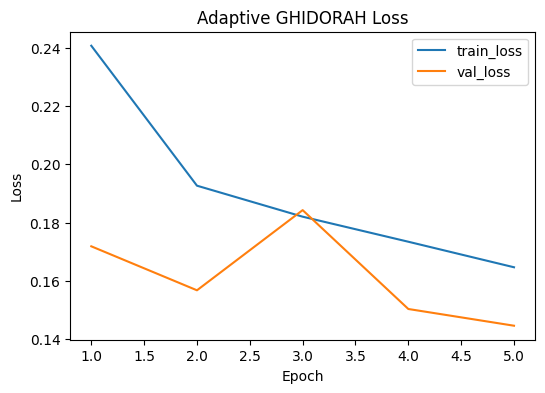

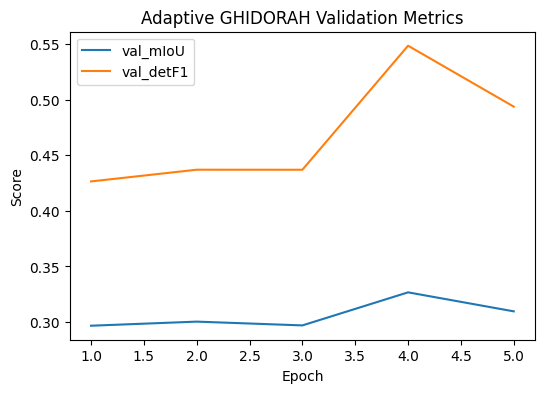

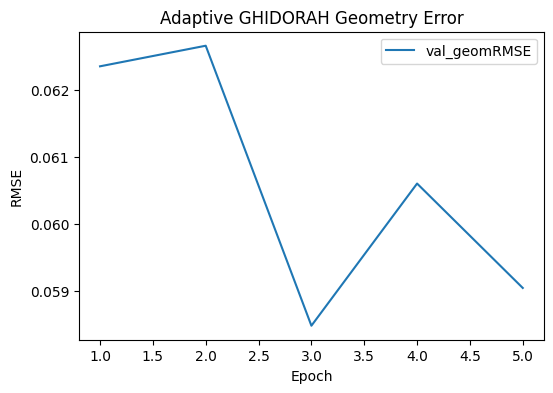

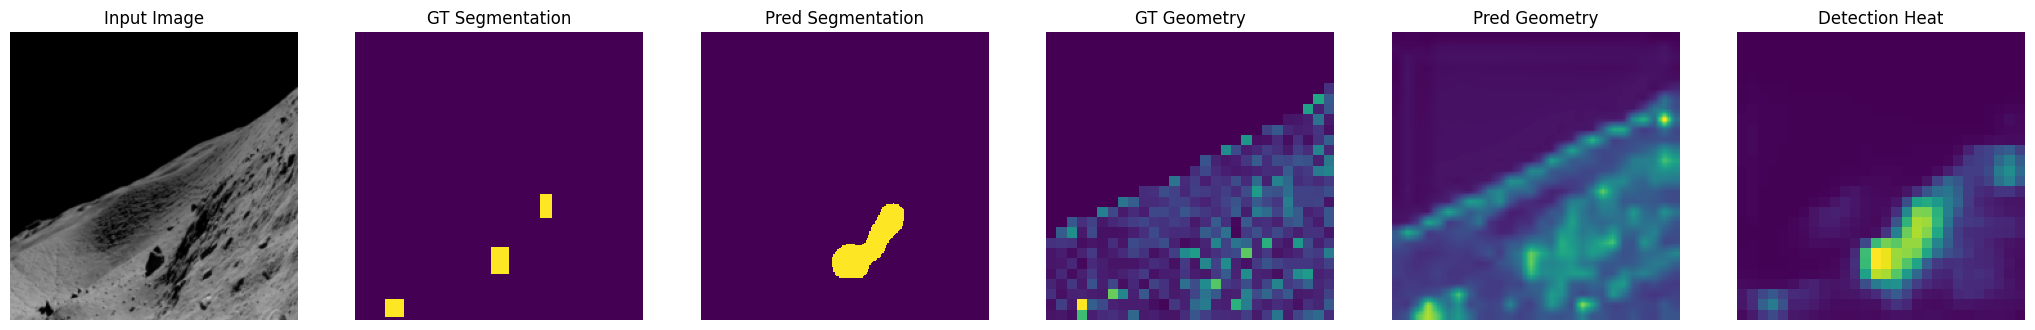

Trunk selections:
  segmentation: TRUNK_FPN_SEMANTIC_LIGHT | avg_weights=['0.347', '0.653']
  detection: TRUNK_DETECTION_PYRAMID_LIGHT | avg_weights=['0.470', '0.530']
  geometry: TRUNK_GEOMETRY_REFINEMENT_LIGHT | avg_weights=['0.349', '0.651']
Terminal selections:
  segmentation: TERM_SEGMENTATION_LIGHT | avg_weights=['0.051', '0.949']
  detection: TERM_DETECTION_LIGHT | avg_weights=['0.210', '0.790']
  geometry: TERM_GEOMETRY_MAP | avg_weights=['0.929', '0.071']
------------------------------------------------------------


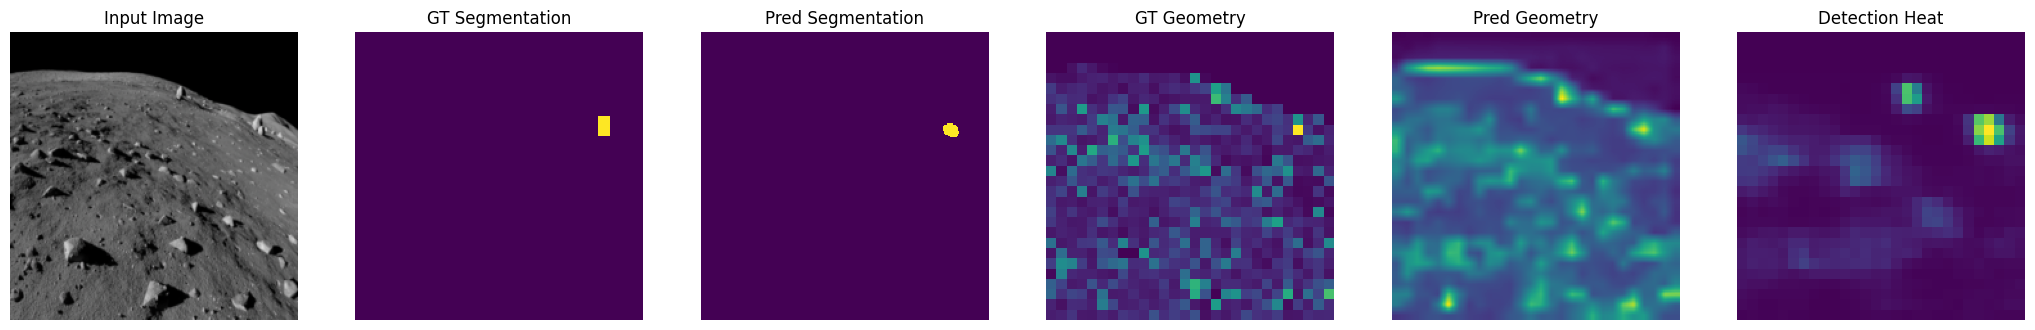

Trunk selections:
  segmentation: TRUNK_FPN_SEMANTIC_LIGHT | avg_weights=['0.347', '0.653']
  detection: TRUNK_DETECTION_PYRAMID_LIGHT | avg_weights=['0.470', '0.530']
  geometry: TRUNK_GEOMETRY_REFINEMENT_LIGHT | avg_weights=['0.349', '0.651']
Terminal selections:
  segmentation: TERM_SEGMENTATION_LIGHT | avg_weights=['0.051', '0.949']
  detection: TERM_DETECTION_LIGHT | avg_weights=['0.210', '0.790']
  geometry: TERM_GEOMETRY_MAP | avg_weights=['0.929', '0.071']
------------------------------------------------------------


In [ ]:

# CELL 45 — HISTORY + PREDICTION VISUALIZATION


plot_training_history(adaptive_history, title_prefix="Adaptive GHIDORAH")
show_prediction_sample(adaptive_model, supervised_loaders["val"], device=device, max_items=2)

In [ ]:
import torch
print(torch.cuda.is_available())

True


========== Training ADAPTIVE GHIDORAH ==========
Epoch 1/3 | train_loss=0.2382 | val_loss=0.1873 | val_mIoU=0.2769 | val_detF1=0.3046 | val_geomRMSE=0.0737 | time=108.5s
Epoch 2/3 | train_loss=0.1928 | val_loss=0.1785 | val_mIoU=0.3080 | val_detF1=0.4643 | val_geomRMSE=0.0599 | time=107.1s
Epoch 3/3 | train_loss=0.1793 | val_loss=0.1479 | val_mIoU=0.3047 | val_detF1=0.4511 | val_geomRMSE=0.0569 | time=107.0s

Best epoch: 2 | Best miou: 0.3080
Checkpoint saved to: /content/ghidorah_adaptive_ablation_adaptive.pt

========== Training FIXED BASELINE ==========
Epoch 1/3 | train_loss=0.2771 | val_loss=0.1876 | val_mIoU=0.2756 | val_detF1=0.2581 | val_geomRMSE=0.0673 | time=99.3s
Epoch 2/3 | train_loss=0.1959 | val_loss=0.1850 | val_mIoU=0.3056 | val_detF1=0.4375 | val_geomRMSE=0.0575 | time=100.7s
Epoch 3/3 | train_loss=0.1854 | val_loss=0.1622 | val_mIoU=0.2975 | val_detF1=0.4336 | val_geomRMSE=0.0608 | time=98.8s

Best epoch: 2 | Best miou: 0.3056
Checkpoint saved to: /content/ghidorah_ad

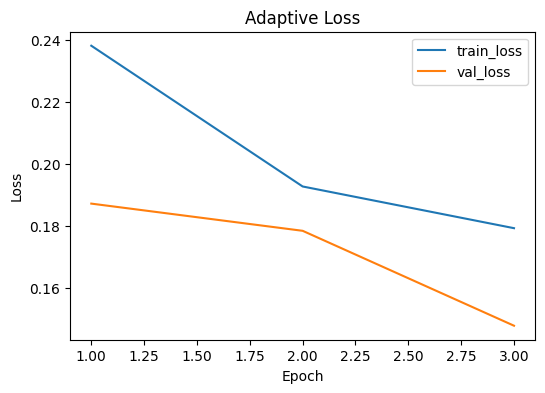

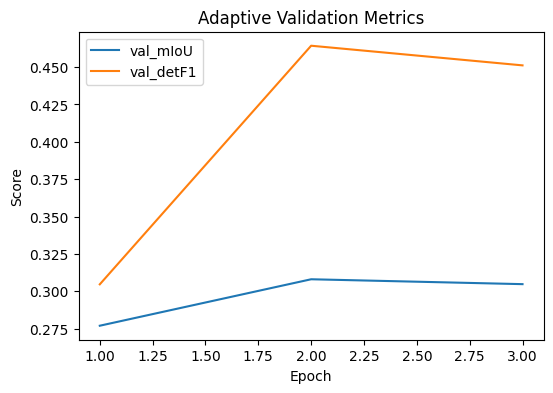

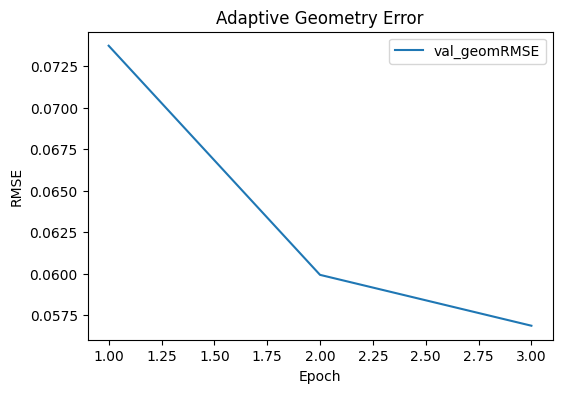

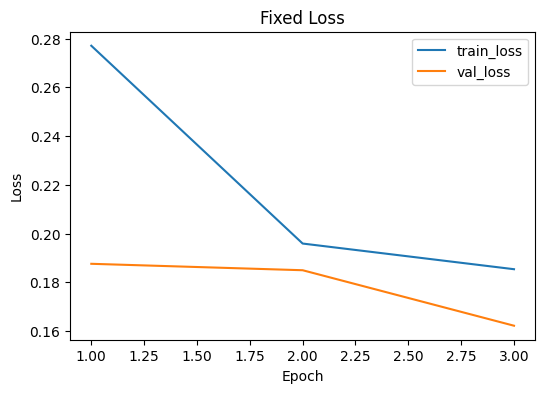

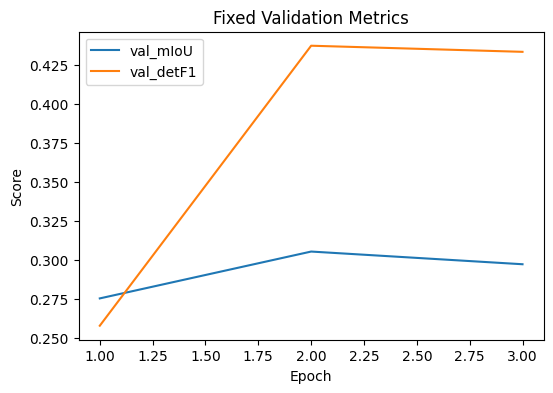

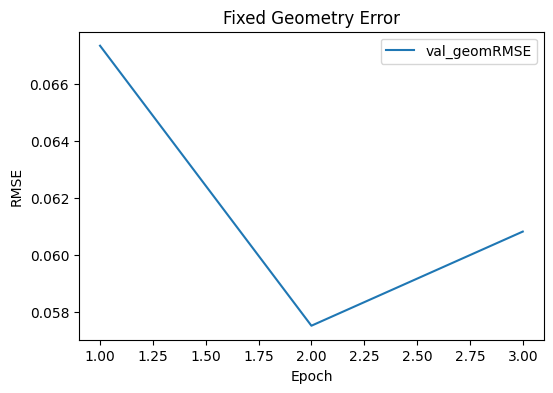

In [ ]:

# CELL 46 — ADAPTIVE VS FIXED ABLATION


ablation_results = run_adaptive_vs_fixed_ablation(
    loaders=supervised_loaders,
    device=device,
    upgrade_config=upgrade_config,
    train_config=TrainConfig(
        epochs=3,
        lr=1e-3,
        weight_decay=1e-4,
        checkpoint_path="/content/ghidorah_adaptive_ablation.pt",
        monitor_metric="miou",
    ),
    loss_config=loss_config,
)

plot_training_history(ablation_results["adaptive_history"], title_prefix="Adaptive")
plot_training_history(ablation_results["fixed_history"], title_prefix="Fixed")

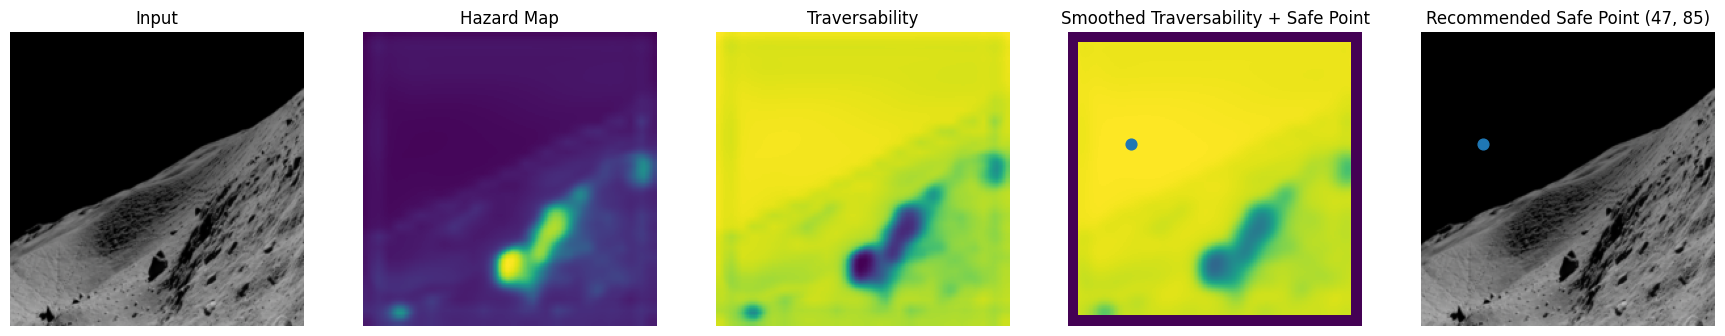

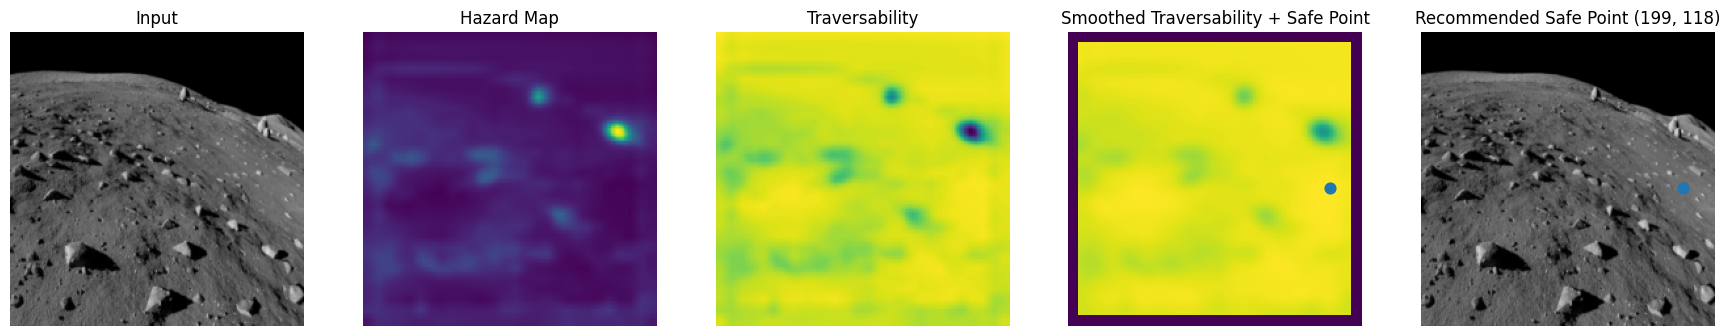

In [ ]:

# CELL 47 — MISSION-FACING OUTPUTS


show_mission_outputs(adaptive_model, supervised_loaders["val"], device=device, max_items=2)

In [ ]:

# CELL 48 — SELECTION LOG INSPECTION


def print_selection_summary(history, split="val", epoch_idx=-1):
    metrics = history[split][epoch_idx]
    counter = metrics["selection_counter"]

    print(f"Selection summary for {split}, epoch index {epoch_idx}")
    for level in ["trunks", "terminals"]:
        print(f"\n{level.upper()}:")
        for task_name, counts in counter[level].items():
            print(f"  {task_name}: {counts}")

print_selection_summary(adaptive_history, split="val", epoch_idx=-1)

Selection summary for val, epoch index -1

TRUNKS:
  segmentation: {'TRUNK_FPN_SEMANTIC_LIGHT': 117}
  detection: {'TRUNK_DETECTION_PYRAMID_LIGHT': 76, 'TRUNK_DETECTION_PYRAMID': 41}
  geometry: {'TRUNK_GEOMETRY_REFINEMENT_LIGHT': 117}

TERMINALS:
  segmentation: {'TERM_SEGMENTATION_LIGHT': 117}
  detection: {'TERM_DETECTION_LIGHT': 117}
  geometry: {'TERM_GEOMETRY_MAP': 117}
